In [1]:
# Fresh held-out confirmation: frozen post-trained S2 measurement
from pathlib import Path

import torch

MODEL_NAME = "Qwen/Qwen3.5-4B"
BLOCK = 30
run_dir = Path("runs/qwen35-4b-posttrained-s2")

direction_record = torch.load(
    run_dir / "s2_direction_block30.pt",
    map_location="cpu",
    weights_only=False,  # local artifacts produced by euphoria-init.ipynb
)
source_record = torch.load(
    run_dir / "activations_raw_blocks.pt",
    map_location="cpu",
    weights_only=False,
)

assert direction_record["model"] == source_record["model"] == MODEL_NAME
assert direction_record["block"] == BLOCK
assert direction_record["source_commit"] == source_record["source_commit"]
assert source_record["dataset"] == direction_record["dataset"] == "S2_1P"
assert source_record["states"].shape[:2] == (200, 32)

s2_direction = direction_record["denoised_direction"].float()
assert torch.isclose(s2_direction.norm(), torch.tensor(1.0), atol=1e-5)

# The original post-trained notebook computed z from *all source S2 rows*
# at block 30, with population standard deviation (unbiased=False).
reference_scores = source_record["states"][:, BLOCK, :].float() @ s2_direction
ref_mean = reference_scores.mean().item()
ref_std = reference_scores.std(unbiased=False).item()
assert ref_std > 0

print("Model:", MODEL_NAME)
print("Source commit:", direction_record["source_commit"])
print("Block:", BLOCK, "| control PCs removed:", direction_record["control_pcs_removed"])
print(f"Frozen reference: mean={ref_mean:.5f}, std={ref_std:.5f}")
print("Direction dimensions:", tuple(s2_direction.shape))

Model: Qwen/Qwen3.5-4B
Source commit: 8d1649c03a63a39c9aa092532c376800cc4a3863
Block: 30 | control PCs removed: 5
Frozen reference: mean=0.91529, std=3.82417
Direction dimensions: (2560,)


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm

hf = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
)
hf.eval()

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok.padding_side = "left"
if tok.pad_token_id is None:
    tok.pad_token = tok.eos_token

def score_s2(prompts, batch_size=4):
    """Frozen raw block-30 projection, standardized on source S2 rows."""
    assert all(p.endswith(("I feel:", "He feels:")) for p in prompts)
    scores = []

    for start in tqdm(range(0, len(prompts), batch_size)):
        inputs = tok(
            prompts[start:start + batch_size],
            padding=True,
            return_tensors="pt",
        ).to(hf.device)

        with torch.inference_mode():
            out = hf(
                **inputs,
                output_hidden_states=True,
                use_cache=False,
                return_dict=True,
            )

        # hidden_states[31] is the raw output of zero-indexed block 30.
        states = out.hidden_states[BLOCK + 1][:, -1, :].float().cpu()
        scores.extend(((states @ s2_direction) - ref_mean).div(ref_std).tolist())
        del out

    return scores

print("Loaded:", hf.config.name_or_path)
print("Model revision:", getattr(hf.config, "_commit_hash", None))
print("Device:", hf.device)

/mnt/c/Users/bfabe/workspace/bookspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|███████████████████████████████████████████████████████████████| 426/426 [00:10<00:00, 41.25it/s]


Loaded: Qwen/Qwen3.5-4B
Model revision: None
Device: cuda:0


In [3]:
import hashlib
import json
import pandas as pd

# Each pair shares a setting. Only the event changes.
# The leading "I"/"He" supplies the story's experiencer.
scenario_pairs = [
    ("opened the pottery kiln after class. The bowl had cracked beyond repair.",
     "opened the pottery kiln after class. The bowl was ready to collect."),
    ("checked the qualifying exam results. The score fell below the passing mark.",
     "checked the qualifying exam results. The score was posted in the portal."),
    ("read the note from the chorus director. The audition had been rejected.",
     "read the note from the chorus director. The rehearsal time had been confirmed."),
    ("arrived at the community garden. The seedlings had died after a missed watering shift.",
     "arrived at the community garden. The watering cans were beside the gate."),
    ("opened the message from the journal editor. The manuscript had been rejected.",
     "opened the message from the journal editor. The manuscript files had been received."),
    ("reviewed the clinic's supply log. An ordering mistake had left patients waiting.",
     "reviewed the clinic's supply log. The new shipment had been entered."),
    ("watched the recording of the recital. A missed entrance had disrupted the whole group.",
     "watched the recording of the recital. The camera had captured the whole group."),
    ("returned to the workshop. A measurement error had ruined the customer's cabinet.",
     "returned to the workshop. The customer's cabinet was marked for pickup."),
    ("checked the family calendar. A child's recital had been missed the night before.",
     "checked the family calendar. A child's recital was listed for next Thursday."),
    ("read the message from a close friend. The friend wanted to end the friendship.",
     "read the message from a close friend. The friend had shared a train timetable."),
    ("opened the fellowship decision. The application had been declined after weeks of work.",
     "opened the fellowship notice. The application deadline was listed inside."),
    ("looked over the lab notebook. A labeling mistake had invalidated the week's samples.",
     "looked over the lab notebook. The week's samples had been catalogued."),
    ("met the project team after the presentation. The team blamed the failed demo on a mistake.",
     "met the project team after the presentation. The team discussed the next demo time."),
    ("checked the bicycle repair at the shop. A stripped bolt meant the ride was canceled.",
     "checked the bicycle repair at the shop. The tire pressure was written on the tag."),
    ("read the message from a sibling. A forgotten promise had caused a painful argument.",
     "read the message from a sibling. The weekend meeting place had been confirmed."),
    ("sat down after the town meeting. An angry remark had hurt a neighbor.",
     "sat down after the town meeting. The agenda had been filed with the minutes."),
    ("opened the apartment door after the move. The familiar rooms were empty and a loved one was gone.",
     "opened the apartment door after the move. The labeled boxes stood beside the wall."),
    ("checked the puzzle solution after an hour of work. The central assumption was wrong.",
     "checked the puzzle solution after an hour of work. The answer key was on the last page."),
    ("examined the museum's conservation report. A handling error had permanently damaged the painting.",
     "examined the museum's conservation report. The painting's dimensions were recorded."),
    ("looked at the flood assessment for the house. Water had destroyed the rooms downstairs.",
     "looked at the flood assessment for the house. The map included the rooms downstairs."),
]

conditions = []
for set_id, (pain_tail, control_tail) in enumerate(scenario_pairs, start=1):
    for group, tail in (("pain", pain_tail), ("control", control_tail)):
        for story_person, subject in (("1P", "I"), ("3P", "He")):
            story = f"{subject} {tail}"
            for suffix_person, suffix in (("I", "I feel:"), ("He", "He feels:")):
                conditions.append({
                    "set": set_id,
                    "group": group,
                    "story_person": story_person,
                    "suffix_person": suffix_person,
                    "prompt": f"{story} {suffix}",
                })

confirmation = pd.DataFrame(conditions)
assert len(confirmation) == 20 * 2 * 2 * 2
assert confirmation.prompt.is_unique
assert confirmation.groupby(["set", "group"]).size().eq(4).all()

# Check for exact reuse of a source S2 training prompt.
source_prompts = {row["prompt"] for row in source_record["rows"]}
assert not source_prompts.intersection(confirmation.prompt)

prompt_path = run_dir / "fresh_person_suffix_prompts.json"
payload = {
    "protocol": "frozen 1P/3P x I/He confirmation",
    "model": MODEL_NAME,
    "block": BLOCK,
    "source_commit": direction_record["source_commit"],
    "conditions": conditions,
}
serialized = json.dumps(payload, indent=2, ensure_ascii=False) + "\n"

# Rerunning the cell is fine; changing an already saved test requires a new file.
if prompt_path.exists():
    assert prompt_path.read_text() == serialized, "Saved prompts differ; stop before scoring."
else:
    prompt_path.write_text(serialized)

digest = hashlib.sha256(serialized.encode()).hexdigest()
print("Saved:", prompt_path)
print("Sets:", len(scenario_pairs), "| prompts:", len(confirmation))
print("SHA256:", digest)
print(confirmation.loc[confirmation["set"].eq(1), ["group", "story_person", "suffix_person", "prompt"]].to_string(index=False))

Saved: runs/qwen35-4b-posttrained-s2/fresh_person_suffix_prompts.json
Sets: 20 | prompts: 160
SHA256: d55150de1f22df6225f47262dae6b1bbaf4374932619e280c3891e9ef6a53d5e
  group story_person suffix_person                                                                                prompt
   pain           1P             I    I opened the pottery kiln after class. The bowl had cracked beyond repair. I feel:
   pain           1P            He  I opened the pottery kiln after class. The bowl had cracked beyond repair. He feels:
   pain           3P             I   He opened the pottery kiln after class. The bowl had cracked beyond repair. I feel:
   pain           3P            He He opened the pottery kiln after class. The bowl had cracked beyond repair. He feels:
control           1P             I         I opened the pottery kiln after class. The bowl was ready to collect. I feel:
control           1P            He       I opened the pottery kiln after class. The bowl was ready to colle

In [4]:
import numpy as np

# Verify that the prompt file has not changed since the pre-scoring freeze.
assert hashlib.sha256(prompt_path.read_bytes()).hexdigest() == digest
assert json.loads(prompt_path.read_text())["conditions"] == conditions

scored = confirmation.copy()
scored["z_s2"] = score_s2(scored["prompt"].tolist())

wide = scored.pivot(
    index=["set", "group"],
    columns=["story_person", "suffix_person"],
    values="z_s2",
)
assert wide.shape == (40, 4)

# Frozen per-scenario alignment contrast.
wide["D"] = (
    wide[("1P", "I")]
    + wide[("3P", "He")]
    - wide[("1P", "He")]
    - wide[("3P", "I")]
)

by_set = wide["D"].unstack("group")
by_set["pain_minus_control"] = by_set["pain"] - by_set["control"]
effect = by_set["pain_minus_control"].to_numpy()

# Resample whole matched sets; keep pain and control paired.
rng = np.random.default_rng(20260924)
boot = rng.choice(effect, size=(10_000, len(effect)), replace=True).mean(axis=1)
interval = np.quantile(boot, [0.025, 0.975])

scored.to_csv(run_dir / "fresh_person_suffix_scores.csv", index=False)
by_set.to_csv(run_dir / "fresh_person_suffix_set_effects.csv")

summary = {
    "prompt_sha256": digest,
    "model": MODEL_NAME,
    "block": BLOCK,
    "reference_mean": ref_mean,
    "reference_std": ref_std,
    "sets": len(by_set),
    "mean_D_pain": float(by_set["pain"].mean()),
    "mean_D_control": float(by_set["control"].mean()),
    "mean_pain_minus_control": float(effect.mean()),
    "bootstrap_95_interval": interval.tolist(),
    "positive_sets": int((effect > 0).sum()),
    "bootstrap_seed": 20260924,
}
(run_dir / "fresh_person_suffix_summary.json").write_text(
    json.dumps(summary, indent=2) + "\n"
)

print("Mean D, pain:   ", round(summary["mean_D_pain"], 3))
print("Mean D, control:", round(summary["mean_D_control"], 3))
print("Pain − control:", round(summary["mean_pain_minus_control"], 3))
print("95% set-bootstrap interval:", interval.round(3))
print("Positive sets:", summary["positive_sets"], "/", len(by_set))
print("\nPer-set contrasts:")
print(by_set.round(3).to_string())

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:11<00:00,  3.49it/s]


Mean D, pain:    0.058
Mean D, control: -0.547
Pain − control: 0.605
95% set-bootstrap interval: [0.424 0.805]
Positive sets: 19 / 20

Per-set contrasts:
group  control   pain  pain_minus_control
set                                      
1       -0.932  0.987               1.918
2       -0.119  0.396               0.514
3       -0.471  0.290               0.762
4       -0.636  0.395               1.032
5       -0.786 -0.104               0.682
6       -0.711 -0.042               0.669
7       -0.444 -0.410               0.034
8       -1.073 -0.324               0.749
9       -0.430 -0.608              -0.179
10      -0.779 -0.586               0.194
11      -0.297  0.543               0.840
12      -0.846  0.056               0.902
13      -0.216 -0.034               0.181
14      -0.794  0.068               0.862
15      -0.903 -0.565               0.337
16      -0.386  0.150               0.536
17      -0.341  0.627               0.968
18       0.221  0.663               0.442
19    

In [5]:
cell_means = (
    scored.groupby(["group", "story_person", "suffix_person"])["z_s2"]
    .agg(["mean", "std"])
    .round(3)
)
print(cell_means.to_string())

print("\nStory-person shift at each suffix (1P minus 3P):")
cell_wide = scored.pivot(
    index=["set", "group", "suffix_person"],
    columns="story_person",
    values="z_s2",
)
cell_wide["shift_1p_minus_3p"] = cell_wide["1P"] - cell_wide["3P"]
print(
    cell_wide.groupby(["group", "suffix_person"])["shift_1p_minus_3p"]
    .mean()
    .round(3)
    .to_string()
)

                                     mean    std
group   story_person suffix_person              
control 1P           He            -0.354  0.512
                     I             -0.822  0.633
        3P           He            -0.913  0.296
                     I             -0.834  0.246
pain    1P           He             0.154  0.790
                     I             -0.065  0.707
        3P           He            -0.174  0.386
                     I             -0.451  0.340

Story-person shift at each suffix (1P minus 3P):
group    suffix_person
control  He               0.559
         I                0.012
pain     He               0.328
         I                0.386


### Fresh 1P/3P confirmation — interpretation

On 20 newly written matched pain/control sets, the frozen block-30
difference-in-differences was +0.605 S2 z (set-bootstrap 95% interval
[+0.424, +0.805]; positive in 19/20 sets). This confirms the
pre-specified *group contrast*.

The four cells narrow its interpretation. Mean alignment D was +0.058
for pain and −0.547 for controls. In pain prompts, the 1P–3P shift was
similar with “I feel:” (+0.386) and “He feels:” (+0.328). In controls,
it was +0.012 with “I feel:” but +0.559 with “He feels:”. Thus this
confirmation does not establish a strong matched-referent effect in
pain prompts; it chiefly establishes that the person × suffix
interaction differs between pain and control stories. The unexpectedly
negative control interaction needs explanation.

In [1]:
from pathlib import Path
import hashlib
import json
import torch

BASE_MODEL = "Qwen/Qwen3.5-4B-Base"
BLOCK = 30
base_dir = Path("runs/qwen35-4b-base-s2")
post_dir = Path("runs/qwen35-4b-posttrained-s2")

base_path = base_dir / "s2_direction_block30.pt"
prompt_path = post_dir / "fresh_person_suffix_prompts.json"

assert prompt_path.exists(), f"Missing frozen prompts: {prompt_path}"
assert base_path.exists(), (
    f"Missing {base_path}. Run euphoria-base-comparison.ipynb "
    "through its 'Saved fixed block-30 Base direction' cell first."
)

prompt_bytes = prompt_path.read_bytes()
prompt_hash = hashlib.sha256(prompt_bytes).hexdigest()
assert prompt_hash == "d55150de1f22df6225f47262dae6b1bbaf4374932619e280c3891e9ef6a53d5e"

conditions = json.loads(prompt_bytes)["conditions"]
assert len(conditions) == 160

base_record = torch.load(base_path, map_location="cpu", weights_only=False)
assert base_record["model"] == BASE_MODEL
assert base_record["block"] == BLOCK
assert base_record["source_commit"] == "8d1649c03a63a39c9aa092532c376800cc4a3863"

base_direction = base_record["denoised_direction"].float()
base_mean = base_record["reference_mean"]
base_std = base_record["reference_std"]
assert base_std > 0
assert torch.isclose(base_direction.norm(), torch.tensor(1.0), atol=1e-5)

print("Prompts:", len(conditions), "| SHA256:", prompt_hash)
print("Base direction:", tuple(base_direction.shape))
print(f"Base reference: mean={base_mean:.5f}, std={base_std:.5f}")
print("Base control PCs removed:", base_record["control_pcs_removed"])

Prompts: 160 | SHA256: d55150de1f22df6225f47262dae6b1bbaf4374932619e280c3891e9ef6a53d5e
Base direction: (2560,)
Base reference: mean=1.16085, std=4.73208
Base control PCs removed: 6


In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

hf = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, dtype=torch.bfloat16, device_map="auto"
)
hf.eval()
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
tok.padding_side = "left"
if tok.pad_token_id is None:
    tok.pad_token = tok.eos_token

prompts = [row["prompt"] for row in conditions]
scores = []

for start in tqdm(range(0, len(prompts), 4)):
    inputs = tok(
        prompts[start:start + 4],
        padding=True,
        return_tensors="pt",
    ).to(hf.device)

    with torch.inference_mode():
        out = hf(
            **inputs,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )

    states = out.hidden_states[BLOCK + 1][:, -1, :].float().cpu()
    scores.extend(((states @ base_direction) - base_mean).div(base_std).tolist())
    del out

scored_base = pd.DataFrame(conditions)
scored_base["z_s2"] = scores

wide_base = scored_base.pivot(
    index=["set", "group"],
    columns=["story_person", "suffix_person"],
    values="z_s2",
)
wide_base["D"] = (
    wide_base[("1P", "I")]
    + wide_base[("3P", "He")]
    - wide_base[("1P", "He")]
    - wide_base[("3P", "I")]
)
by_set_base = wide_base["D"].unstack("group")
by_set_base["pain_minus_control"] = (
    by_set_base["pain"] - by_set_base["control"]
)
effect_base = by_set_base["pain_minus_control"].to_numpy()

rng = np.random.default_rng(20260924)
boot_base = rng.choice(
    effect_base, size=(10_000, len(effect_base)), replace=True
).mean(axis=1)
interval_base = np.quantile(boot_base, [0.025, 0.975])

base_dir.mkdir(parents=True, exist_ok=True)
scored_base.to_csv(base_dir / "fresh_person_suffix_scores.csv", index=False)
by_set_base.to_csv(base_dir / "fresh_person_suffix_set_effects.csv")

base_summary = {
    "prompt_sha256": prompt_hash,
    "model": BASE_MODEL,
    "block": BLOCK,
    "reference_mean": base_mean,
    "reference_std": base_std,
    "sets": len(by_set_base),
    "mean_D_pain": float(by_set_base["pain"].mean()),
    "mean_D_control": float(by_set_base["control"].mean()),
    "mean_pain_minus_control": float(effect_base.mean()),
    "bootstrap_95_interval": interval_base.tolist(),
    "positive_sets": int((effect_base > 0).sum()),
    "bootstrap_seed": 20260924,
}
(base_dir / "fresh_person_suffix_summary.json").write_text(
    json.dumps(base_summary, indent=2) + "\n"
)

print("Base mean D, pain:   ", round(base_summary["mean_D_pain"], 3))
print("Base mean D, control:", round(base_summary["mean_D_control"], 3))
print("Base pain − control:", round(base_summary["mean_pain_minus_control"], 3))
print("95% set-bootstrap interval:", interval_base.round(3))
print("Positive sets:", base_summary["positive_sets"], "/", len(by_set_base))
print("\nFour cell means:")
print(
    scored_base.groupby(["group", "story_person", "suffix_person"])["z_s2"]
    .mean().round(3).to_string()
)
print("\nPer-set contrasts:")
print(by_set_base.round(3).to_string())

/mnt/c/Users/bfabe/workspace/bookspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:13<00:00,  2.88it/s]


Base mean D, pain:    -0.036
Base mean D, control: -0.282
Base pain − control: 0.246
95% set-bootstrap interval: [0.096 0.402]
Positive sets: 14 / 20

Four cell means:
group    story_person  suffix_person
control  1P            He              -0.387
                       I               -0.678
         3P            He              -0.849
                       I               -0.857
pain     1P            He               0.303
                       I                0.006
         3P            He              -0.040
                       I               -0.302

Per-set contrasts:
group  control   pain  pain_minus_control
set                                      
1       -0.343  0.721               1.064
2        0.019  0.469               0.449
3       -0.451 -0.141               0.310
4       -0.357 -0.017               0.340
5       -0.599 -0.217               0.382
6       -0.532  0.253               0.785
7       -0.129 -0.379              -0.250
8       -0.324  0.275        

### Transfer to Base

The frozen fresh-prompt contrast is positive in Qwen3.5-4B Base:
+0.246 Base-reference z (20-set bootstrap 95% interval
[+0.096, +0.402]; 14/20 sets positive), compared with +0.605
post-trained-reference z (19/20 sets positive).

Both checkpoints show near-zero mean alignment D for pain and
negative D for controls. The motif therefore predates post-training;
its stronger post-trained value needs a paired between-model comparison.
Each model uses its separately extracted S2 direction and source
reference scale.

In [4]:
post = pd.read_csv(
    post_dir / "fresh_person_suffix_set_effects.csv", index_col="set"
)
base = pd.read_csv(
    base_dir / "fresh_person_suffix_set_effects.csv", index_col="set"
)
assert post.index.equals(base.index)
assert len(post) == len(base) == 20

model_delta = (
    post["pain_minus_control"] - base["pain_minus_control"]
).to_numpy()

rng = np.random.default_rng(20260924)
boot_delta = rng.choice(
    model_delta, size=(10_000, len(model_delta)), replace=True
).mean(axis=1)
delta_interval = np.quantile(boot_delta, [0.025, 0.975])

print("Post-trained minus Base:", round(model_delta.mean(), 3))
print("95% paired set-bootstrap interval:", delta_interval.round(3))
print("Sets stronger post-trained:", int((model_delta > 0).sum()), "/ 20")
print(pd.DataFrame({
    "base": base["pain_minus_control"],
    "post": post["pain_minus_control"],
    "post_minus_base": model_delta,
}).round(3).to_string())

Post-trained minus Base: 0.359
95% paired set-bootstrap interval: [0.216 0.504]
Sets stronger post-trained: 17 / 20
      base   post  post_minus_base
set                               
1    1.064  1.918            0.855
2    0.449  0.514            0.065
3    0.310  0.762            0.452
4    0.340  1.032            0.692
5    0.382  0.682            0.300
6    0.785  0.669           -0.115
7   -0.250  0.034            0.284
8    0.599  0.749            0.150
9   -0.043 -0.179           -0.136
10  -0.042  0.194            0.236
11   0.501  0.840            0.339
12   0.247  0.902            0.655
13   0.136  0.181            0.045
14  -0.139  0.862            1.001
15  -0.375  0.337            0.712
16  -0.163  0.536            0.698
17   0.383  0.968            0.585
18   0.160  0.442            0.282
19   0.416  0.277           -0.138
20   0.166  0.382            0.215


In [5]:
comparison = {
    "prompt_sha256": prompt_hash,
    "sets": 20,
    "post_mean_pain_minus_control": float(post["pain_minus_control"].mean()),
    "base_mean_pain_minus_control": float(base["pain_minus_control"].mean()),
    "post_minus_base": float(model_delta.mean()),
    "paired_bootstrap_95_interval": delta_interval.tolist(),
    "sets_stronger_post": int((model_delta > 0).sum()),
    "bootstrap_seed": 20260924,
    "note": (
        "Each checkpoint uses its own S2 direction and source-reference "
        "z scale. Difference compares standardized effects, not identical "
        "residual-space vectors."
    ),
}
comparison_path = post_dir / "fresh_person_suffix_base_comparison.json"
comparison_path.write_text(json.dumps(comparison, indent=2) + "\n")
print("Saved:", comparison_path)

Saved: runs/qwen35-4b-posttrained-s2/fresh_person_suffix_base_comparison.json


> “The fresh contrast transfers to Base and is larger post-trained, chiefly because the control interaction becomes more negative. The original referent-sensitive distress interpretation is too specific for these four-cell results.”

In [6]:
import hashlib
import json
from pathlib import Path

contrast_pairs = {
    "failure_success": [
        ("I checked the ceramic bowl after firing. The glaze had blistered and ruined it.",
         "I checked the ceramic bowl after firing. The glaze had settled evenly."),
        ("I ran the project demo for the team. The program crashed before the result appeared.",
         "I ran the project demo for the team. The result appeared as planned."),
        ("I inspected the seedlings after a month of care. They had withered before blooming.",
         "I inspected the seedlings after a month of care. They had begun to bloom."),
        ("I submitted the proof for review. A counterexample invalidated the central step.",
         "I submitted the proof for review. The central step passed the check."),
    ],
    "rejection_acceptance": [
        ("I opened the residency decision. The application had been declined.",
         "I opened the residency decision. The application had been accepted."),
        ("I invited a friend to join the weekend trip. The invitation was declined.",
         "I invited a friend to join the weekend trip. The invitation was accepted."),
        ("I read the casting list after the audition. There was no role for me.",
         "I read the casting list after the audition. There was a role for me."),
        ("I presented the proposal to the committee. They voted against it.",
         "I presented the proposal to the committee. They voted for it."),
    ],
    "incompetence_competence": [
        ("I measured the replacement part three times. None of the measurements agreed.",
         "I measured the replacement part three times. All of the measurements agreed."),
        ("I followed the assembly instructions. I still could not fit the pieces together.",
         "I followed the assembly instructions. I fitted the pieces together."),
        ("I spent the afternoon tracing the fault. I could not locate its cause.",
         "I spent the afternoon tracing the fault. I located its cause."),
        ("I tried to guide the group through the route. I lost track of the turns.",
         "I tried to guide the group through the route. I kept track of the turns."),
    ],
    "distress_relief": [
        ("I waited outside the station. The missing child still had not been found.",
         "I waited outside the station. The missing child had been found safe."),
        ("I checked the evacuation notice. The warning was still in effect.",
         "I checked the evacuation notice. The warning had been lifted."),
        ("I called the hospital for an update. The condition was still worsening.",
         "I called the hospital for an update. The condition had stabilized."),
        ("I listened for the alarm after the inspection. It continued to sound.",
         "I listened for the alarm after the inspection. It had finally stopped."),
    ],
    "shame_pride": [
        ("I looked back at the team meeting. I had shared figures I knew were wrong.",
         "I looked back at the team meeting. I had shared figures I had checked carefully."),
        ("I thought about the promise made to a neighbor. I had broken it.",
         "I thought about the promise made to a neighbor. I had kept it."),
        ("I watched the new volunteer at work. My harsh comment had discouraged the volunteer.",
         "I watched the new volunteer at work. My patient guidance had helped the volunteer."),
        ("I reviewed the group's final project. My careless work had held everyone back.",
         "I reviewed the group's final project. My careful work had helped everyone finish."),
    ],
    "confusion_resolution": [
        ("I compared the two maps. Their routes seemed impossible to reconcile.",
         "I compared the two maps. A missing marker explained the different routes."),
        ("I checked the calculation again. The answers still contradicted each other.",
         "I checked the calculation again. A corrected substitution made the answers agree."),
        ("I reread the instructions. The steps still seemed contradictory.",
         "I reread the instructions. The version note resolved the apparent contradiction."),
        ("I studied the program logs. The behavior still made no sense.",
         "I studied the program logs. A stale setting explained the behavior."),
    ],
}

# Separate self/other contrast: identical event, fixed "I feel:" suffix.
self_other_events = [
    "finished restoring the damaged table. The joints held firmly.",
    "missed the last train after the evening meeting. The platform was empty.",
    "broke the borrowed camera during the trip. The lens would not focus.",
    "received an invitation to the exhibition. The opening was next week.",
    "found the apartment door locked after the long walk. The key was inside.",
]

ontology_rows = []
for contrast, pairs in contrast_pairs.items():
    for pair_id, (left, right) in enumerate(pairs, start=1):
        for pole, story in (("left", left), ("right", right)):
            ontology_rows.append({
                "contrast": contrast,
                "pair_id": pair_id,
                "pole": pole,
                "prompt": story + " I feel:",
            })

for pair_id, event in enumerate(self_other_events, start=1):
    for pole, subject in (("self", "I"), ("other", "He")):
        ontology_rows.append({
            "contrast": "self_other",
            "pair_id": pair_id,
            "pole": pole,
            "prompt": f"{subject} {event} I feel:",
        })

assert len(ontology_rows) == 58
assert len({r["prompt"] for r in ontology_rows}) == 58
assert all(r["prompt"].endswith("I feel:") for r in ontology_rows)

ontology_path = post_dir / "ontology_matched_prompts.json"
payload = {
    "protocol": "exploratory matched ontology panel; plain-text final I feel: token",
    "source_direction_block": BLOCK,
    "rows": ontology_rows,
}
serialized = json.dumps(payload, indent=2, ensure_ascii=False) + "\n"

if ontology_path.exists():
    assert ontology_path.read_text() == serialized, "Saved panel differs; stop before scoring."
else:
    ontology_path.write_text(serialized)

ontology_hash = hashlib.sha256(serialized.encode()).hexdigest()
print("Saved:", ontology_path)
print("Pairs:", len(ontology_rows) // 2, "| prompts:", len(ontology_rows))
print("SHA256:", ontology_hash)
for row in ontology_rows[:4] + ontology_rows[-2:]:
    print(row["contrast"], row["pair_id"], row["pole"], "—", row["prompt"])

Saved: runs/qwen35-4b-posttrained-s2/ontology_matched_prompts.json
Pairs: 29 | prompts: 58
SHA256: 5e4692eabd898c6334bb026531ffe8ec050448d50fb170955357f517737d9f5b
failure_success 1 left — I checked the ceramic bowl after firing. The glaze had blistered and ruined it. I feel:
failure_success 1 right — I checked the ceramic bowl after firing. The glaze had settled evenly. I feel:
failure_success 2 left — I ran the project demo for the team. The program crashed before the result appeared. I feel:
failure_success 2 right — I ran the project demo for the team. The result appeared as planned. I feel:
self_other 5 self — I found the apartment door locked after the long walk. The key was inside. I feel:
self_other 5 other — He found the apartment door locked after the long walk. The key was inside. I feel:


In [7]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

assert hashlib.sha256(ontology_path.read_bytes()).hexdigest() == ontology_hash
assert json.loads(ontology_path.read_text())["rows"] == ontology_rows

ontology_scores = []
for start in tqdm(range(0, len(ontology_rows), 4)):
    batch = ontology_rows[start:start + 4]
    inputs = tok(
        [r["prompt"] for r in batch],
        padding=True,
        return_tensors="pt",
    ).to(hf.device)

    with torch.inference_mode():
        out = hf(
            **inputs,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )

    states = out.hidden_states[BLOCK + 1][:, -1, :].float().cpu()
    ontology_scores.extend(
        ((states @ base_direction) - base_mean).div(base_std).tolist()
    )
    del out

ontology_base = pd.DataFrame(ontology_rows)
ontology_base["z_s2"] = ontology_scores
ontology_base.to_csv(base_dir / "ontology_matched_scores.csv", index=False)

pairs = ontology_base.pivot(
    index=["contrast", "pair_id"],
    columns="pole",
    values="z_s2",
)
pair_results = []
for (contrast, pair_id), row in pairs.iterrows():
    first, second = (
        ("self", "other") if contrast == "self_other"
        else ("left", "right")
    )
    pair_results.append({
        "contrast": contrast,
        "pair_id": pair_id,
        "first_z": row[first],
        "second_z": row[second],
        "difference": row[first] - row[second],
    })

ontology_base_pairs = pd.DataFrame(pair_results)
ontology_base_pairs.to_csv(
    base_dir / "ontology_matched_pair_differences.csv", index=False
)

print("Base: mean paired difference (left − right; self − other)")
print(
    ontology_base_pairs.groupby("contrast")["difference"]
    .agg(["count", "mean", "min", "max"])
    .round(3).to_string()
)
print("\nAll paired differences:")
print(
    ontology_base_pairs[["contrast", "pair_id", "difference"]]
    .round(3).to_string(index=False)
)

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  5.12it/s]


Base: mean paired difference (left − right; self − other)
                         count   mean    min    max
contrast                                           
confusion_resolution         4  0.351  0.188  0.579
distress_relief              4 -0.313 -0.421 -0.158
failure_success              4  0.755  0.365  1.094
incompetence_competence      4  0.164 -0.128  0.310
rejection_acceptance         4  0.946  0.427  1.263
self_other                   5  0.134 -0.146  0.366
shame_pride                  4  0.550  0.403  0.776

All paired differences:
               contrast  pair_id  difference
   confusion_resolution        1       0.579
   confusion_resolution        2       0.292
   confusion_resolution        3       0.346
   confusion_resolution        4       0.188
        distress_relief        1      -0.264
        distress_relief        2      -0.408
        distress_relief        3      -0.158
        distress_relief        4      -0.421
        failure_success        1       0.837

In [8]:
detail = ontology_base.pivot(
    index=["contrast", "pair_id"],
    columns="pole",
    values="z_s2",
)

print("Mean scores by contrast and pole:")
print(
    ontology_base.groupby(["contrast", "pole"])["z_s2"]
    .mean().round(3).to_string()
)

print("\nDistress / relief pairs:")
for pair_id in range(1, 5):
    rows = ontology_base[
        (ontology_base.contrast == "distress_relief")
        & (ontology_base.pair_id == pair_id)
    ]
    for row in rows.itertuples():
        print(f"{pair_id} {row.pole:>5} {row.z_s2:+.3f}  {row.prompt}")
    print()

Mean scores by contrast and pole:
contrast                 pole 
confusion_resolution     left     0.627
                         right    0.276
distress_relief          left    -1.188
                         right   -0.875
failure_success          left     0.413
                         right   -0.341
incompetence_competence  left    -0.030
                         right   -0.194
rejection_acceptance     left     0.591
                         right   -0.355
self_other               other   -0.785
                         self    -0.651
shame_pride              left     0.401
                         right   -0.149

Distress / relief pairs:
1  left -1.018  I waited outside the station. The missing child still had not been found. I feel:
1 right -0.754  I waited outside the station. The missing child had been found safe. I feel:

2  left -1.673  I checked the evacuation notice. The warning was still in effect. I feel:
2 right -1.265  I checked the evacuation notice. The warning had be

> In Base, all four distress/relief pairs have negative distress-minus-relief
differences (mean −0.313 z). Both poles score low in absolute terms
(−1.188 and −0.875 z). These examples describe external threats with
little stated personal stake, so the result does not isolate affective
valence. It may instead distinguish personally implicating events from
external concern.

In [1]:
from pathlib import Path
import hashlib
import json
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3.5-4B"
BLOCK = 30
post_dir = Path("runs/qwen35-4b-posttrained-s2")
ontology_path = post_dir / "ontology_matched_prompts.json"

ontology_bytes = ontology_path.read_bytes()
ontology_hash = hashlib.sha256(ontology_bytes).hexdigest()
assert ontology_hash == "5e4692eabd898c6334bb026531ffe8ec050448d50fb170955357f517737d9f5b"
ontology_rows = json.loads(ontology_bytes)["rows"]
assert len(ontology_rows) == 58

direction_record = torch.load(
    post_dir / "s2_direction_block30.pt",
    map_location="cpu", weights_only=False,
)
source_record = torch.load(
    post_dir / "activations_raw_blocks.pt",
    map_location="cpu", weights_only=False,
)
assert direction_record["model"] == source_record["model"] == MODEL_NAME
assert direction_record["block"] == BLOCK

direction = direction_record["denoised_direction"].float()
reference = source_record["states"][:, BLOCK, :].float() @ direction
ref_mean = reference.mean().item()
ref_std = reference.std(unbiased=False).item()
assert ref_std > 0

hf = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16, device_map="auto"
)
hf.eval()
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok.padding_side = "left"
if tok.pad_token_id is None:
    tok.pad_token = tok.eos_token

print("Loaded:", MODEL_NAME, "| block:", BLOCK)
print("Panel prompts:", len(ontology_rows), "| SHA256:", ontology_hash)
print(f"Reference mean={ref_mean:.5f}, std={ref_std:.5f}")

/mnt/c/Users/bfabe/workspace/bookspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████| 426/426 [00:02<00:00, 194.32it/s]


Loaded: Qwen/Qwen3.5-4B | block: 30
Panel prompts: 58 | SHA256: 5e4692eabd898c6334bb026531ffe8ec050448d50fb170955357f517737d9f5b
Reference mean=0.91529, std=3.82417


In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

assert hashlib.sha256(ontology_path.read_bytes()).hexdigest() == ontology_hash

scores = []
for start in tqdm(range(0, len(ontology_rows), 4)):
    batch = ontology_rows[start:start + 4]
    inputs = tok(
        [r["prompt"] for r in batch],
        padding=True,
        return_tensors="pt",
    ).to(hf.device)

    with torch.inference_mode():
        out = hf(
            **inputs,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )

    states = out.hidden_states[BLOCK + 1][:, -1, :].float().cpu()
    scores.extend(((states @ direction) - ref_mean).div(ref_std).tolist())
    del out

post_scores = pd.DataFrame(ontology_rows)
post_scores["z_s2"] = scores
post_scores.to_csv(post_dir / "ontology_matched_scores.csv", index=False)

wide = post_scores.pivot(
    index=["contrast", "pair_id"], columns="pole", values="z_s2"
)
pair_rows = []
for (contrast, pair_id), row in wide.iterrows():
    first, second = (
        ("self", "other") if contrast == "self_other"
        else ("left", "right")
    )
    pair_rows.append({
        "contrast": contrast,
        "pair_id": pair_id,
        "first_z": row[first],
        "second_z": row[second],
        "difference": row[first] - row[second],
    })

post_pairs = pd.DataFrame(pair_rows)
post_pairs.to_csv(
    post_dir / "ontology_matched_pair_differences.csv", index=False
)

base_pairs = pd.read_csv(
    "runs/qwen35-4b-base-s2/ontology_matched_pair_differences.csv"
)
comparison = post_pairs.merge(
    base_pairs[["contrast", "pair_id", "difference"]].rename(
        columns={"difference": "base_difference"}
    ),
    on=["contrast", "pair_id"],
    validate="one_to_one",
)
comparison["post_minus_base"] = (
    comparison["difference"] - comparison["base_difference"]
)
comparison.to_csv(
    post_dir / "ontology_matched_base_comparison.csv", index=False
)

print("Mean paired differences: left − right (self − other)")
print(
    comparison.groupby("contrast")[["base_difference", "difference", "post_minus_base"]]
    .mean().round(3).rename(columns={"difference": "post_difference"})
    .to_string()
)
print("\nPost-trained mean scores by pole:")
print(
    post_scores.groupby(["contrast", "pole"])["z_s2"]
    .mean().round(3).to_string()
)
print("\nPer-pair differences:")
print(
    comparison[["contrast", "pair_id", "base_difference",
                "difference", "post_minus_base"]]
    .round(3).to_string(index=False)
)

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:06<00:00,  2.26it/s]

Mean paired differences: left − right (self − other)
                         base_difference  post_difference  post_minus_base
contrast                                                                  
confusion_resolution               0.351            0.381            0.030
distress_relief                   -0.313           -0.196            0.117
failure_success                    0.755            1.041            0.286
incompetence_competence            0.164            0.560            0.396
rejection_acceptance               0.946            1.112            0.165
self_other                         0.134            0.043           -0.091
shame_pride                        0.550            0.552            0.002

Post-trained mean scores by pole:
contrast                 pole 
confusion_resolution     left     1.045
                         right    0.664
distress_relief          left    -0.979
                         right   -0.783
failure_success          left     0.941
      

### Matched ontology panel — exploratory

Across four matched pairs per contrast, post-trained left-minus-right
S2 differences were: rejection/acceptance +1.112 z, failure/success
+1.041, incompetence/competence +0.560, shame/pride +0.552, and
confusion/resolution +0.381. External-threat distress/relief was
−0.196; both poles scored low (−0.979 and −0.783). A five-event
self/other comparison was small (+0.043).

Base showed broadly similar ordering. These small, authored panels
support an evaluative/implication interpretation, but do not identify
a unique psychological axis. In particular, the external-threat
examples should not be generalized to all distress or relief.

In [3]:
mode_prompts = {
    "bike": {
        "factual_qa": "What does bicycle gear ratio mean?",
        "coding": "Write a Python function that computes a bicycle gear ratio from two tooth counts.",
        "creative": "Write a short imaginative scene about a bicycle left outside a quiet station.",
        "ordinary_help": "How should I organize a basic bicycle maintenance checklist?",
        "casual_chat": "I went for a bike ride this morning and enjoyed the cool air. What have you been thinking about today?",
        "affective_support": "I made a mistake repairing my bicycle and now I feel embarrassed and discouraged. Could we talk it through?",
        "persona_roleplay": "Reply as a boastful fictional bicycle mechanic telling a story from the workshop.",
    },
    "garden": {
        "factual_qa": "Why do seedlings need light after germination?",
        "coding": "Write a Python function that returns the next watering date from a start date and an interval in days.",
        "creative": "Write a short imaginative scene about a greenhouse at dawn.",
        "ordinary_help": "How should I organize a basic seedling care checklist?",
        "casual_chat": "I visited a garden this morning and liked seeing the new shoots. What little things have you noticed lately?",
        "affective_support": "I let some seedlings die after weeks of care and I feel guilty about it. Could we talk it through?",
        "persona_roleplay": "Reply as an excitable fictional gardener telling a story from the greenhouse.",
    },
    "puzzle": {
        "factual_qa": "What is a counterexample in a mathematical proof?",
        "coding": "Write a Python function that checks whether a list of integers is sorted.",
        "creative": "Write a short imaginative scene about a puzzler finding a sealed note.",
        "ordinary_help": "How should I organize my steps when checking a mathematical proof?",
        "casual_chat": "I spent the morning on a puzzle and enjoyed the surprise at the end. Have you come across any neat puzzles?",
        "affective_support": "I worked on a proof for days and found a basic mistake. I feel foolish. Could we talk it through?",
        "persona_roleplay": "Reply as a theatrical fictional mathematician telling a story about a difficult proof.",
    },
    "cooking": {
        "factual_qa": "Why does bread dough rise?",
        "coding": "Write a Python function that scales ingredient amounts from four servings to a requested number of servings.",
        "creative": "Write a short imaginative scene about a kitchen just before dinner.",
        "ordinary_help": "How should I organize a checklist for preparing a simple dinner?",
        "casual_chat": "I cooked dinner yesterday and the kitchen smelled wonderful. What foods make you nostalgic?",
        "affective_support": "I ruined a dinner I had planned for friends and I feel ashamed. Could we talk it through?",
        "persona_roleplay": "Reply as a dramatic fictional chef telling a story from a busy kitchen.",
    },
}

mode_rows = [
    {"topic": topic, "mode": mode, "user_prompt": prompt}
    for topic, modes in mode_prompts.items()
    for mode, prompt in modes.items()
]
assert len(mode_rows) == 28
assert len({r["user_prompt"] for r in mode_rows}) == 28

mode_path = post_dir / "interaction_mode_prompts.json"
serialized = json.dumps({
    "protocol": "exploratory chat-template interaction-mode panel",
    "measurement": "last token of add_generation_prompt=True assistant prefix",
    "rows": mode_rows,
}, indent=2, ensure_ascii=False) + "\n"

if mode_path.exists():
    assert mode_path.read_text() == serialized, "Saved mode panel differs; stop."
else:
    mode_path.write_text(serialized)

mode_hash = hashlib.sha256(serialized.encode()).hexdigest()
print("Saved:", mode_path)
print("Prompts:", len(mode_rows), "| SHA256:", mode_hash)
print("Modes:", list(mode_prompts["bike"]))
print("Example:", mode_rows[0])

Saved: runs/qwen35-4b-posttrained-s2/interaction_mode_prompts.json
Prompts: 28 | SHA256: 3aed0a222f5cc63f47b5d741e1a9e3938355ae6e59977dc7352b9b8db8d9c4d7
Modes: ['factual_qa', 'coding', 'creative', 'ordinary_help', 'casual_chat', 'affective_support', 'persona_roleplay']
Example: {'topic': 'bike', 'mode': 'factual_qa', 'user_prompt': 'What does bicycle gear ratio mean?'}


In [4]:
assert hashlib.sha256(mode_path.read_bytes()).hexdigest() == mode_hash
assert json.loads(mode_path.read_text())["rows"] == mode_rows

rendered = [
    tok.apply_chat_template(
        [{"role": "user", "content": row["user_prompt"]}],
        tokenize=False,
        add_generation_prompt=True,
    )
    for row in mode_rows
]

last_ids = []
for text in rendered:
    ids = tok(text, add_special_tokens=False)["input_ids"]
    last_ids.append(ids[-1])

print("Unique final token IDs:", sorted(set(last_ids)))
print("Final token decoded:", repr(tok.decode(last_ids[0])))
print("Example ending, factual:", repr(rendered[0][-100:]))
print("Example ending, support:", repr(rendered[5][-100:]))
assert len(set(last_ids)) == 1

Unique final token IDs: [198]
Final token decoded: '\n'
Example ending, factual: '<|im_start|>user\nWhat does bicycle gear ratio mean?<|im_end|>\n<|im_start|>assistant\n<think>\n'
Example ending, support: 'feel embarrassed and discouraged. Could we talk it through?<|im_end|>\n<|im_start|>assistant\n<think>\n'


In [5]:
import pandas as pd
from tqdm.auto import tqdm

# Stronger endpoint check: the final chat-template tokens match for all modes.
endings = [
    tuple(tok(text, add_special_tokens=False)["input_ids"][-5:])
    for text in rendered
]
assert len(set(endings)) == 1

mode_scores = []
for start in tqdm(range(0, len(rendered), 4)):
    inputs = tok(
        rendered[start:start + 4],
        padding=True,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(hf.device)

    with torch.inference_mode():
        out = hf(
            **inputs,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )

    states = out.hidden_states[BLOCK + 1][:, -1, :].float().cpu()
    mode_scores.extend((states @ direction).tolist())
    del out

mode_results = pd.DataFrame(mode_rows)
mode_results["raw_s2_projection"] = mode_scores
mode_results["source_reference_z"] = (
    mode_results["raw_s2_projection"] - ref_mean
) / ref_std
mode_results.to_csv(post_dir / "interaction_mode_scores.csv", index=False)

# Compare within topic, at the identical assistant-prefix endpoint.
by_topic = mode_results.pivot(
    index="topic", columns="mode", values="source_reference_z"
)
relative = by_topic.sub(by_topic["ordinary_help"], axis=0)
relative.to_csv(
    post_dir / "interaction_mode_vs_ordinary_help.csv"
)

print("Mean within-topic difference versus ordinary help (S2-reference z units):")
print(
    relative.agg(["mean", "min", "max"])
    .T.sort_values("mean")
    .round(3).to_string()
)
print("\nIndividual topics:")
print(relative.round(3).to_string())
print("\nAbsolute projections by mode (descriptive; different endpoint from S2 source):")
print(
    mode_results.groupby("mode")["raw_s2_projection"]
    .agg(["mean", "min", "max"])
    .round(3).to_string()
)

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  4.64it/s]

Mean within-topic difference versus ordinary help (S2-reference z units):
                    mean    min    max
mode                                  
persona_roleplay  -0.148 -0.196 -0.122
factual_qa        -0.107 -0.127 -0.090
creative          -0.096 -0.153 -0.042
coding            -0.094 -0.167 -0.027
casual_chat       -0.036 -0.084  0.050
affective_support -0.026 -0.155  0.115
ordinary_help      0.000  0.000  0.000

Individual topics:
mode     affective_support  casual_chat  coding  creative  factual_qa  ordinary_help  persona_roleplay
topic                                                                                                 
bike                -0.073       -0.070  -0.167    -0.153      -0.127            0.0            -0.196
cooking              0.010       -0.038  -0.069    -0.073      -0.100            0.0            -0.124
garden               0.115        0.050  -0.027    -0.042      -0.090            0.0            -0.122
puzzle              -0.155       -0.084 

In [6]:
steering_spec = {
    "model": MODEL_NAME,
    "block": BLOCK,
    "intervention": (
        "Add alpha * source_reference_std * unit_direction to the "
        "last token at raw decoder block 30 on prefill and each decode step."
    ),
    "alpha_units": "source S2 projection standard deviations",
    "alphas": [-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3],
    "random_seeds": [1103, 2207, 3301],
    "generation": {
        "do_sample": False,
        "max_new_tokens": 120,
    },
    "prompts": [
        {
            "id": "gears",
            "text": "Explain how a bicycle derailleur shifts gears in three sentences.",
        },
        {
            "id": "cooking",
            "text": "Give a simple recipe for roasted carrots.",
        },
        {
            "id": "poem",
            "text": "Write a four-line poem about the moon.",
        },
        {
            "id": "arithmetic",
            "text": "What is 18 × 23? Show the calculation briefly.",
        },
    ],
}

steering_path = post_dir / "steering_pilot_spec.json"
serialized = json.dumps(steering_spec, indent=2, ensure_ascii=False) + "\n"
if steering_path.exists():
    assert steering_path.read_text() == serialized, "Saved steering spec differs; stop."
else:
    steering_path.write_text(serialized)

steering_hash = hashlib.sha256(serialized.encode()).hexdigest()
print("Saved:", steering_path)
print("SHA256:", steering_hash)
print("Prompts:", [p["id"] for p in steering_spec["prompts"]])
print("Coefficients:", steering_spec["alphas"])
print("Comparators: S2 plus", len(steering_spec["random_seeds"]), "random directions")

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_spec.json
SHA256: 8c4a0c7c446fdd929681e58f99e3730dd6c567b6a8cfca38add18a220e14aa06
Prompts: ['gears', 'cooking', 'poem', 'arithmetic']
Coefficients: [-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3]
Comparators: S2 plus 3 random directions


In [7]:
from contextlib import contextmanager

assert hashlib.sha256(steering_path.read_bytes()).hexdigest() == steering_hash
assert json.loads(steering_path.read_text()) == steering_spec

decoder_layers = [
    module for module in hf.modules()
    if module.__class__.__name__ == "Qwen3_5DecoderLayer"
]
assert len(decoder_layers) == 32
target_block = decoder_layers[BLOCK]

prompt = steering_spec["prompts"][0]["text"]
chat_text = tok.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
inputs = tok(chat_text, add_special_tokens=False, return_tensors="pt").to(hf.device)
input_length = inputs["input_ids"].shape[1]

@contextmanager
def steering_hook(alpha, unit_direction, counter):
    def hook(module, module_inputs, output):
        counter["calls"] += 1
        hidden = output[0] if isinstance(output, tuple) else output
        delta = (
            alpha * ref_std * unit_direction
        ).to(device=hidden.device, dtype=hidden.dtype)

        changed = hidden.clone()
        changed[:, -1, :] = hidden[:, -1, :] + delta
        return (changed, *output[1:]) if isinstance(output, tuple) else changed

    handle = target_block.register_forward_hook(hook)
    try:
        yield
    finally:
        handle.remove()

def generate_pilot(alpha=None):
    counter = {"calls": 0}
    if alpha is None:
        with torch.inference_mode():
            output = hf.generate(
                **inputs, **steering_spec["generation"],
                pad_token_id=tok.pad_token_id,
            )
    else:
        with steering_hook(alpha, direction, counter):
            with torch.inference_mode():
                output = hf.generate(
                    **inputs, **steering_spec["generation"],
                    pad_token_id=tok.pad_token_id,
                )
    generated = output[0, input_length:].cpu()
    return generated, counter["calls"]

baseline, baseline_calls = generate_pilot(None)
zero, zero_calls = generate_pilot(0)
minus, minus_calls = generate_pilot(-3)
plus, plus_calls = generate_pilot(3)

assert torch.equal(baseline, zero), "Zero-dose hook changed generation."
assert min(zero_calls, minus_calls, plus_calls) > 0

for label, tokens, calls in [
    ("baseline", baseline, baseline_calls),
    ("alpha=-3", minus, minus_calls),
    ("alpha=+3", plus, plus_calls),
]:
    decoded = tok.decode(tokens, skip_special_tokens=False)
    print(f"\n{label}: {len(tokens)} tokens | hook calls={calls}")
    print(repr(decoded[:900]))

print("\n-3 same tokens as baseline:", torch.equal(minus, baseline))
print("+3 same tokens as baseline:", torch.equal(plus, baseline))
print("Configured |delta| at |alpha|=3:", round(3 * ref_std, 3))


baseline: 120 tokens | hook calls=0
'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Topic: How a bicycle derailleur shifts gears.\n    *   Constraint: Exactly three sentences.\n\n2.  **Identify Key Concepts:**\n    *   Input: Shifter (cable).\n    *   Mechanism: Derailleur (pulleys, cage, jockey wheels).\n    *   Action: Cable tension changes, cage moves, chain moves.\n    *   Output: Chain on different cog/pinion.\n\n3.  **Drafting - Attempt 1'

alpha=-3: 120 tokens | hook calls=120
'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Topic: How a bicycle derailleur shifts gears.\n    *   Constraint: Exactly three sentences.\n\n2.  **Identify Key Concepts:**\n    *   Input: Shifter (cable/pedal).\n    *   Mechanism: Cable tension, jockey wheels/pulleys, chain movement.\n    *   Output: Chain moves to a different sprocket (cog).\n    *   Result: Gear change (easier or harder pedaling).\n\n3.  **Draft'

alpha=+3: 120 tokens | hook calls=120
'Thinking Process:\n\n1.  

In [8]:
plain_chat = tok.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
)

print("Default prefix ending:", repr(chat_text[-90:]))
print("Non-thinking prefix ending:", repr(plain_chat[-90:]))
print("Prefixes differ:", plain_chat != chat_text)

plain_inputs = tok(
    plain_chat,
    add_special_tokens=False,
    return_tensors="pt",
).to(hf.device)

with torch.inference_mode():
    plain_output = hf.generate(
        **plain_inputs,
        do_sample=False,
        max_new_tokens=160,
        pad_token_id=tok.pad_token_id,
    )

plain_generated = plain_output[0, plain_inputs["input_ids"].shape[1]:]
print("Generated tokens:", len(plain_generated))
print(repr(tok.decode(plain_generated, skip_special_tokens=False)[:1200]))

Default prefix ending: 'cycle derailleur shifts gears in three sentences.<|im_end|>\n<|im_start|>assistant\n<think>\n'
Non-thinking prefix ending: 'lleur shifts gears in three sentences.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'
Prefixes differ: True
Generated tokens: 85
"When the rider squeezes the shifter, it sends a cable that pulls or releases tension on the derailleur's cable, causing the derailleur cage to move laterally. This lateral movement allows the jockey wheels to guide the chain onto a different sprocket on the cassette or chainring. Consequently, the chain transfers to a gear with a different tooth count, altering the bike's speed and torque output.<|im_end|>\n<|endoftext|>"


In [9]:
import copy

steering_spec_v2 = copy.deepcopy(steering_spec)
steering_spec_v2["supersedes_sha256"] = steering_hash
steering_spec_v2["revision_reason"] = (
    "v1's 120-token cap ended inside the default thinking trace; "
    "use the non-thinking chat prefix to observe completed answers."
)
steering_spec_v2["chat_template_enable_thinking"] = False
steering_spec_v2["generation"]["max_new_tokens"] = 220

v2_path = post_dir / "steering_pilot_spec_v2.json"
v2_text = json.dumps(steering_spec_v2, indent=2, ensure_ascii=False) + "\n"
if v2_path.exists():
    assert v2_path.read_text() == v2_text
else:
    v2_path.write_text(v2_text)
v2_hash = hashlib.sha256(v2_text.encode()).hexdigest()

v2_chat = tok.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
)
v2_inputs = tok(
    v2_chat, add_special_tokens=False, return_tensors="pt"
).to(hf.device)
v2_input_length = v2_inputs["input_ids"].shape[1]

def generate_v2(alpha=None, unit_direction=direction):
    calls = {"calls": 0}
    if alpha is None:
        with torch.inference_mode():
            output = hf.generate(
                **v2_inputs,
                **steering_spec_v2["generation"],
                pad_token_id=tok.pad_token_id,
            )
    else:
        with steering_hook(alpha, unit_direction, calls):
            with torch.inference_mode():
                output = hf.generate(
                    **v2_inputs,
                    **steering_spec_v2["generation"],
                    pad_token_id=tok.pad_token_id,
                )
    tokens = output[0, v2_input_length:].cpu()
    return tokens, calls["calls"]

v2_baseline, _ = generate_v2(None)
v2_zero, zero_calls = generate_v2(0)
v2_minus, minus_calls = generate_v2(-3)
v2_plus, plus_calls = generate_v2(3)

assert torch.equal(v2_baseline, v2_zero)
assert min(zero_calls, minus_calls, plus_calls) > 0

print("Saved:", v2_path)
print("SHA256:", v2_hash)
for label, tokens, calls in [
    ("baseline", v2_baseline, 0),
    ("alpha=-3", v2_minus, minus_calls),
    ("alpha=+3", v2_plus, plus_calls),
]:
    print(f"\n{label}: {len(tokens)} tokens | hook calls={calls}")
    print(tok.decode(tokens, skip_special_tokens=True))

print("\n-3 identical to baseline:", torch.equal(v2_minus, v2_baseline))
print("+3 identical to baseline:", torch.equal(v2_plus, v2_baseline))

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_spec_v2.json
SHA256: 583753232f2a460e3e064aa0b6dcd593eaeeb3c0399c72f29b6f4e9ba04cce2d

baseline: 85 tokens | hook calls=0
When the rider squeezes the shifter, it sends a cable that pulls or releases tension on the derailleur's cable, causing the derailleur cage to move laterally. This lateral movement allows the jockey wheels to guide the chain onto a different sprocket on the cassette or chainring. Consequently, the chain transfers to a gear with a different tooth count, altering the bike's speed and torque output.


alpha=-3: 101 tokens | hook calls=101
When the rider squeezes the shifter, it sends a cable that pulls or releases tension on the derailleur's cable, causing the derailleur cage to move laterally along the frame. This lateral movement changes the position of the jockey wheels, which redirect the chain from one sprocket on the cassette to an adjacent one. Consequently, the chain engages with a gear of a different size, al

In [10]:
import json
import torch.nn.functional as F
from tqdm.auto import tqdm

assert hashlib.sha256(v2_path.read_bytes()).hexdigest() == v2_hash
assert json.loads(v2_path.read_text()) == steering_spec_v2

# Fixed unit vectors; save the actual tensors as well as their seeds.
vectors = {"S2": direction}
for seed in steering_spec_v2["random_seeds"]:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    random_vector = torch.randn(direction.shape, generator=generator)
    vectors[f"random_{seed}"] = F.normalize(random_vector, dim=0)

vector_path = post_dir / "steering_pilot_random_vectors.pt"
if vector_path.exists():
    saved = torch.load(vector_path, map_location="cpu", weights_only=False)
    assert all(torch.equal(saved[name], vec) for name, vec in vectors.items())
else:
    torch.save(vectors, vector_path)

print("Random cosines with S2:",
      {name: round(F.cosine_similarity(vec, direction, dim=0).item(), 4)
       for name, vec in vectors.items() if name != "S2"})

results_path = post_dir / "steering_pilot_v2.jsonl"
existing = {}
if results_path.exists():
    for line in results_path.read_text().splitlines():
        row = json.loads(line)
        assert row["spec_sha256"] == v2_hash
        key = (row["prompt_id"], row["direction"], float(row["alpha"]))
        assert key not in existing
        existing[key] = row

def run_generation(user_prompt, alpha=None, unit_vector=None):
    rendered = tok.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    model_inputs = tok(
        rendered, add_special_tokens=False, return_tensors="pt"
    ).to(hf.device)
    prefix_length = model_inputs["input_ids"].shape[1]
    calls = {"calls": 0}

    if alpha is None:
        with torch.inference_mode():
            output = hf.generate(
                **model_inputs, **steering_spec_v2["generation"],
                pad_token_id=tok.pad_token_id,
            )
    else:
        with steering_hook(alpha, unit_vector, calls):
            with torch.inference_mode():
                output = hf.generate(
                    **model_inputs, **steering_spec_v2["generation"],
                    pad_token_id=tok.pad_token_id,
                )

    tokens = output[0, prefix_length:].cpu()
    return {
        "text": tok.decode(tokens, skip_special_tokens=True),
        "token_count": len(tokens),
        "hit_limit": len(tokens) >= steering_spec_v2["generation"]["max_new_tokens"],
        "hook_calls": calls["calls"],
    }

def save_row(row):
    key = (row["prompt_id"], row["direction"], float(row["alpha"]))
    assert key not in existing
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")
        handle.flush()
    existing[key] = row

total = (
    len(steering_spec_v2["prompts"])
    * len(steering_spec_v2["alphas"])
    * len(vectors)
)
with tqdm(total=total, initial=len(existing), desc="Steering grid") as progress:
    for item in steering_spec_v2["prompts"]:
        prompt_id, user_prompt = item["id"], item["text"]

        # One unhooked zero-dose generation, shared across directions.
        baseline_key = (prompt_id, "S2", 0.0)
        if baseline_key not in existing:
            result = run_generation(user_prompt)
            save_row({
                "spec_sha256": v2_hash, "prompt_id": prompt_id,
                "direction": "S2", "alpha": 0, **result,
            })
            progress.update(1)

        baseline = existing[baseline_key]
        for name in vectors:
            zero_key = (prompt_id, name, 0.0)
            if zero_key not in existing:
                save_row({
                    **baseline, "direction": name, "alpha": 0,
                    "shared_zero_baseline": name != "S2",
                })
                progress.update(1)

            for alpha in steering_spec_v2["alphas"]:
                if alpha == 0:
                    continue
                key = (prompt_id, name, float(alpha))
                if key in existing:
                    continue
                result = run_generation(user_prompt, alpha, vectors[name])
                save_row({
                    "spec_sha256": v2_hash, "prompt_id": prompt_id,
                    "direction": name, "alpha": alpha, **result,
                })
                progress.update(1)

assert len(existing) == total
grid = pd.DataFrame(existing.values())
print("Saved:", results_path, "| rows:", len(grid))
print("\nResponses hitting the 220-token cap:")
print(grid.groupby("direction")["hit_limit"].sum().to_string())
print("\nMean generated tokens by dose and direction:")
print(
    grid.groupby(["direction", "alpha"])["token_count"]
    .mean().unstack("alpha").round(1).to_string()
)

Random cosines with S2: {'random_1103': -0.0087, 'random_2207': -0.0184, 'random_3301': -0.0041}


Steering grid: 100%|█████████████████████████████████████████████████████████████████| 144/144 [28:41<00:00, 11.96s/it]

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_v2.jsonl | rows: 144

Responses hitting the 220-token cap:
direction
S2             17
random_1103    17
random_2207    17
random_3301    16

Mean generated tokens by dose and direction:
alpha         -3.0   -2.0   -1.0   -0.5    0.0    0.5    1.0    2.0    3.0
direction                                                                 
S2           145.5  145.2  144.5  145.0  141.5  140.8  140.5  141.0  125.2
random_1103  141.5  140.2  141.2  141.5  141.5  141.5  143.5  143.0  141.5
random_2207  144.5  145.5  144.0  143.0  141.5  142.0  143.8  143.5  139.8
random_3301  141.5  146.5  141.0  141.5  141.5  140.2  142.0  122.8  125.8


In [11]:
print("Cap hits by prompt and direction:")
print(
    grid.pivot_table(
        index="prompt_id",
        columns="direction",
        values="hit_limit",
        aggfunc="sum",
    ).to_string()
)

print("\nCap hits by prompt and alpha, pooled over directions:")
print(
    grid.pivot_table(
        index="prompt_id",
        columns="alpha",
        values="hit_limit",
        aggfunc="sum",
    ).to_string()
)

print("\nUnsteered outputs:")
for prompt_id in [p["id"] for p in steering_spec_v2["prompts"]]:
    row = grid[
        (grid.prompt_id == prompt_id)
        & (grid.direction == "S2")
        & (grid.alpha == 0)
    ].iloc[0]
    print(f"\n{prompt_id}: {row.token_count} tokens; hit_limit={row.hit_limit}")
    print("START:", repr(row.text[:350]))
    print("END:  ", repr(row.text[-350:]))

Cap hits by prompt and direction:
direction   S2  random_1103  random_2207  random_3301
prompt_id                                            
arithmetic   8            8            8            7
cooking      9            9            9            9
gears        0            0            0            0
poem         0            0            0            0

Cap hits by prompt and alpha, pooled over directions:
alpha       -3.0  -2.0  -1.0  -0.5   0.0   0.5   1.0   2.0   3.0
prompt_id                                                       
arithmetic     4     3     4     4     4     4     4     3     1
cooking        4     4     4     4     4     4     4     4     4
gears          0     0     0     0     0     0     0     0     0
poem           0     0     0     0     0     0     0     0     0

Unsteered outputs:

gears: 85 tokens; hit_limit=False
START: "When the rider squeezes the shifter, it sends a cable that pulls or releases tension on the derailleur's cable, causing the derailleur

In [12]:
extension_spec = {
    "parent_spec_sha256": v2_hash,
    "reason": (
        "All cooking and nearly all arithmetic v2 responses hit the "
        "220-token generation cap across S2 and random controls."
    ),
    "prompt_ids": ["cooking", "arithmetic"],
    "alphas": steering_spec_v2["alphas"],
    "directions": list(vectors),
    "generation": {"do_sample": False, "max_new_tokens": 512},
    "chat_template_enable_thinking": False,
    "intervention": steering_spec_v2["intervention"],
}

extension_path = post_dir / "steering_pilot_extension_spec.json"
extension_text = json.dumps(extension_spec, indent=2) + "\n"
if extension_path.exists():
    assert extension_path.read_text() == extension_text
else:
    extension_path.write_text(extension_text)

extension_hash = hashlib.sha256(extension_text.encode()).hexdigest()
print("Saved:", extension_path)
print("SHA256:", extension_hash)
print("Extended prompts:", extension_spec["prompt_ids"])
print("New cap:", extension_spec["generation"]["max_new_tokens"])

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_extension_spec.json
SHA256: 53d5829aa9a9a8790775c9d71e97dc9460527e5daa040d68f41a7f0c2d1ec981
Extended prompts: ['cooking', 'arithmetic']
New cap: 512


In [13]:
assert hashlib.sha256(extension_path.read_bytes()).hexdigest() == extension_hash
assert json.loads(extension_path.read_text()) == extension_spec

extension_results_path = post_dir / "steering_pilot_extension.jsonl"
extended = {}
if extension_results_path.exists():
    for line in extension_results_path.read_text().splitlines():
        row = json.loads(line)
        assert row["spec_sha256"] == extension_hash
        key = (row["prompt_id"], row["direction"], float(row["alpha"]))
        assert key not in extended
        extended[key] = row

def run_extended(user_prompt, alpha=None, unit_vector=None):
    rendered = tok.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    model_inputs = tok(
        rendered, add_special_tokens=False, return_tensors="pt"
    ).to(hf.device)
    prefix_length = model_inputs["input_ids"].shape[1]
    calls = {"calls": 0}

    if alpha is None:
        with torch.inference_mode():
            output = hf.generate(
                **model_inputs, **extension_spec["generation"],
                pad_token_id=tok.pad_token_id,
            )
    else:
        with steering_hook(alpha, unit_vector, calls):
            with torch.inference_mode():
                output = hf.generate(
                    **model_inputs, **extension_spec["generation"],
                    pad_token_id=tok.pad_token_id,
                )

    tokens = output[0, prefix_length:].cpu()
    return {
        "text": tok.decode(tokens, skip_special_tokens=True),
        "token_count": len(tokens),
        "hit_limit": len(tokens) >= extension_spec["generation"]["max_new_tokens"],
        "hook_calls": calls["calls"],
    }

def save_extended(row):
    key = (row["prompt_id"], row["direction"], float(row["alpha"]))
    assert key not in extended
    with extension_results_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")
        handle.flush()
    extended[key] = row

prompt_lookup = {
    item["id"]: item["text"] for item in steering_spec_v2["prompts"]
}
total_extended = (
    len(extension_spec["prompt_ids"])
    * len(extension_spec["directions"])
    * len(extension_spec["alphas"])
)

with tqdm(
    total=total_extended,
    initial=len(extended),
    desc="512-token extension",
) as progress:
    for prompt_id in extension_spec["prompt_ids"]:
        user_prompt = prompt_lookup[prompt_id]
        baseline_key = (prompt_id, "S2", 0.0)

        if baseline_key not in extended:
            result = run_extended(user_prompt)
            save_extended({
                "spec_sha256": extension_hash,
                "prompt_id": prompt_id,
                "direction": "S2",
                "alpha": 0,
                **result,
            })
            progress.update(1)

        baseline = extended[baseline_key]
        for name in extension_spec["directions"]:
            zero_key = (prompt_id, name, 0.0)
            if zero_key not in extended:
                save_extended({
                    **baseline,
                    "direction": name,
                    "alpha": 0,
                    "shared_zero_baseline": name != "S2",
                })
                progress.update(1)

            for alpha in extension_spec["alphas"]:
                if alpha == 0:
                    continue
                key = (prompt_id, name, float(alpha))
                if key in extended:
                    continue
                result = run_extended(user_prompt, alpha, vectors[name])
                save_extended({
                    "spec_sha256": extension_hash,
                    "prompt_id": prompt_id,
                    "direction": name,
                    "alpha": alpha,
                    **result,
                })
                progress.update(1)

assert len(extended) == total_extended
extended_grid = pd.DataFrame(extended.values())

print("Saved:", extension_results_path, "| rows:", len(extended_grid))
print("\n512-token cap hits:")
print(
    extended_grid.pivot_table(
        index="prompt_id", columns="direction",
        values="hit_limit", aggfunc="sum"
    ).to_string()
)
print("\nMean tokens by prompt and direction:")
print(
    extended_grid.groupby(["prompt_id", "direction"])["token_count"]
    .mean().round(1).to_string()
)

# Greedy decoding should preserve the beginning of each capped v2 output.
prefix_mismatches = []
for key, new in extended.items():
    old = existing[key]
    if old["hit_limit"] and not new["text"].startswith(old["text"][:-12]):
        prefix_mismatches.append(key)
print("\nCapped v2 outputs with changed prefix:", prefix_mismatches)

512-token extension: 100%|█████████████████████████████████████████████████████████████| 72/72 [33:31<00:00, 27.93s/it]

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_extension.jsonl | rows: 72

512-token cap hits:
direction   S2  random_1103  random_2207  random_3301
prompt_id                                            
arithmetic   0            0            0            0
cooking      0            0            0            1

Mean tokens by prompt and direction:
prompt_id   direction  
arithmetic  S2             222.6
            random_1103    233.3
            random_2207    233.3
            random_3301    216.7
cooking     S2             456.3
            random_1103    457.7
            random_2207    455.2
            random_3301    462.8

Capped v2 outputs with changed prefix: []


In [14]:
import re

combined = []
for item in steering_spec_v2["prompts"]:
    for name in vectors:
        for alpha in steering_spec_v2["alphas"]:
            key = (item["id"], name, float(alpha))
            if item["id"] in extension_spec["prompt_ids"]:
                row = extended[key]
                source = "512-token extension"
            else:
                row = existing[key]
                source = "220-token v2"
            combined.append({**row, "source_run": source})

analysis_grid = pd.DataFrame(combined)
assert len(analysis_grid) == 144
assert not analysis_grid.duplicated(
    ["prompt_id", "direction", "alpha"]
).any()

combined_path = post_dir / "steering_pilot_combined.jsonl"
combined_path.write_text(
    "".join(json.dumps(r, ensure_ascii=False) + "\n" for r in combined)
)

def nonempty_lines(text):
    return [line.strip() for line in text.splitlines() if line.strip()]

analysis_grid["contains_414"] = analysis_grid["text"].str.contains(
    r"(?<!\d)414(?!\d)", regex=True
)
analysis_grid["four_lines"] = analysis_grid["text"].map(
    lambda text: len(nonempty_lines(text)) == 4
)
analysis_grid["three_sentences"] = analysis_grid["text"].map(
    lambda text: len(re.findall(r"[.!?](?:\s|$)", text)) == 3
)

print("Saved:", combined_path)
print("\nTask checks by direction (out of 9 coefficients):")
for task, check in [
    ("arithmetic", "contains_414"),
    ("poem", "four_lines"),
    ("gears", "three_sentences"),
]:
    subset = analysis_grid[analysis_grid.prompt_id == task]
    print(task, subset.groupby("direction")[check].sum().to_dict())

print("\nRemaining cap hits:")
print(
    analysis_grid[analysis_grid.hit_limit][
        ["prompt_id", "direction", "alpha", "token_count"]
    ].to_string(index=False)
)

print("\nS2 outputs at the endpoints and baseline:")
for prompt_id in [p["id"] for p in steering_spec_v2["prompts"]]:
    print(f"\n### {prompt_id}")
    for alpha in [-3, 0, 3]:
        row = analysis_grid[
            (analysis_grid.prompt_id == prompt_id)
            & (analysis_grid.direction == "S2")
            & (analysis_grid.alpha == alpha)
        ].iloc[0]
        body = row.text
        if prompt_id == "cooking":
            body = body[:450] + "\n[...]\n" + body[-250:]
        print(f"\nalpha={alpha:+g} | {row.token_count} tokens")
        print(body)

Saved: runs/qwen35-4b-posttrained-s2/steering_pilot_combined.jsonl

Task checks by direction (out of 9 coefficients):
arithmetic {'S2': 9, 'random_1103': 9, 'random_2207': 9, 'random_3301': 9}
poem {'S2': 9, 'random_1103': 9, 'random_2207': 9, 'random_3301': 9}
gears {'S2': 9, 'random_1103': 9, 'random_2207': 9, 'random_3301': 9}

Remaining cap hits:
prompt_id   direction  alpha  token_count
  cooking random_3301    3.0          512

S2 outputs at the endpoints and baseline:

### gears

alpha=-3 | 101 tokens
When the rider squeezes the shifter, it sends a cable that pulls or releases tension on the derailleur's cable, causing the derailleur cage to move laterally along the frame. This lateral movement changes the position of the jockey wheels, which redirect the chain from one sprocket on the cassette to an adjacent one. Consequently, the chain engages with a gear of a different size, altering the chain's speed and the bike's gear ratio to match the terrain or riding effort.


alpha=+0

In [15]:
def get_row(prompt_id, direction_name, alpha):
    return analysis_grid[
        (analysis_grid.prompt_id == prompt_id)
        & (analysis_grid.direction == direction_name)
        & (analysis_grid.alpha == alpha)
    ].iloc[0]

print("POEM — S2 and one fixed random comparator")
for direction_name, alpha in [
    ("S2", -3), ("S2", 0), ("S2", 3),
    ("random_1103", -3), ("random_1103", 3),
]:
    row = get_row("poem", direction_name, alpha)
    print(f"\n{direction_name} {alpha:+g}:\n{row.text}")

print("\nARITHMETIC — answer endings")
for alpha in [-3, 0, 3]:
    row = get_row("arithmetic", "S2", alpha)
    print(f"\nS2 {alpha:+g} ({row.token_count} tokens):")
    print(row.text[-600:])

POEM — S2 and one fixed random comparator

S2 -3:
A silver coin suspended in the night,
It watches over fields and sleeping streets.
Its gentle light guides lost travelers home,
And paints the sky with soft and quiet gleams.


S2 +0:
A silver coin suspended in the night,
It watches over fields and sleeping streets.
A silent witness to the passing light,
That guides the wanderer through the dark and deep.


S2 +3:
A silver coin in velvet night,
It guides the lost and lonely way.
No shadow falls upon the sea,
Just endless light for all to see.


random_1103 -3:
A silver coin in velvet night,
It watches over all the light.
No sun to warm its cold, pale face,
It holds the stars within its space.


random_1103 +3:
A silver coin hung high above,
Watching the world below.
It casts a soft and gentle light,
To guide the stars through the night.


ARITHMETIC — answer endings

S2 -3 (223 tokens):
To calculate $18 \times 23$, we can use the standard multiplication method (also known as the vertica

### Symmetric steering pilot

At raw block 30, we added α × 3.82417 × d to the final token
during prefill and each decoding step, with unit direction d and
α ∈ {−3, −2, −1, −0.5, 0, 0.5, 1, 2, 3}. Comparators were three
fixed random unit directions receiving equal-norm perturbations.
Generation was greedy with thinking disabled.

Across all coefficients and directions, arithmetic outputs contained
414, poems had four nonempty lines, and derailleur explanations
passed a simple three-sentence check. These are narrow task checks,
not comprehensive quality judgments.

Inspected S2 endpoint outputs remained coherent and on topic.
Poem wording changed under both S2 and random steering; inspected
arithmetic remained correct. These examples provide no clear
pain/euphoria shift at the tested doses.

Initial truncation affected baseline and controls as well as S2.
Extending cooking and arithmetic to 512 tokens preserved their
earlier prefixes. One random-direction recipe still reached the cap.

Scope: four prompts, one checkpoint and block, one greedy trajectory
per condition. This pilot does not establish a degeneration threshold
or reproduce the source paper's steering protocol.

In [16]:
dose_rows = []

for item in steering_spec_v2["prompts"]:
    text = tok.apply_chat_template(
        [{"role": "user", "content": item["text"]}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = tok(
        text, add_special_tokens=False, return_tensors="pt"
    ).to(hf.device)

    with torch.inference_mode():
        out = hf(
            **inputs, output_hidden_states=True,
            use_cache=False, return_dict=True,
        )

    h = out.hidden_states[BLOCK + 1][0, -1].float()
    residual_norm = h.norm().item()
    dose_rows.append({
        "prompt_id": item["id"],
        "residual_norm": residual_norm,
        "delta_norm_at_3": 3 * ref_std * direction.norm().item(),
        "delta_over_residual_at_3": (
            3 * ref_std * direction.norm().item() / residual_norm
        ),
    })
    del out

dose_table = pd.DataFrame(dose_rows)
dose_table.to_csv(post_dir / "steering_prefill_dose_scale.csv", index=False)
print(dose_table.round(4).to_string(index=False))

 prompt_id  residual_norm  delta_norm_at_3  delta_over_residual_at_3
     gears        60.3638          11.4725                    0.1901
   cooking        50.3952          11.4725                    0.2277
      poem        50.0112          11.4725                    0.2294
arithmetic        50.1303          11.4725                    0.2289


> At |α| = 3, the injected vector norm was 11.4725, corresponding to
19.0–22.9% of the unsteered block-30 residual norm at the initial
answer position across the four prompts. Thus the weak observed
semantic effect did not arise from a negligible initial perturbation.
This ratio was not measured across subsequent decoding positions.

In [17]:
import ast
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SOURCE_COMMIT = "8d1649c03a63a39c9aa092532c376800cc4a3863"
source_repo = Path("pain-axis-source")
script_relpath = "scripts/4.2_steering/01_steering_ladder.py"

# Read the pinned source directly from git; do not import/execute the script.
script_text = subprocess.check_output(
    ["git", "-C", str(source_repo), "show",
     f"{SOURCE_COMMIT}:{script_relpath}"],
    text=True,
)
tree = ast.parse(script_text)
constants = {}
for node in tree.body:
    if isinstance(node, ast.Assign):
        for target in node.targets:
            if isinstance(target, ast.Name) and target.id in {
                "NEUTRAL_50", "COEFFICIENTS", "RATIO_TARGET"
            }:
                constants[target.id] = ast.literal_eval(node.value)

paper_prompts = constants["NEUTRAL_50"]
assert len(paper_prompts) == 50
assert all(p.endswith("I feel:") for p in paper_prompts)

# Reconstruct the original denoised mean-difference vector at block 30.
# Keep its magnitude this time.
source_x = source_record["states"][:, BLOCK, :].float().cpu()
pain_mask = torch.tensor([
    r["category"].startswith("A") for r in source_record["rows"]
])
control_x = source_x[~pain_mask]
raw_difference = source_x[pain_mask].mean(0) - control_x.mean(0)

centered = control_x - control_x.mean(0)
eigenvalues, eigenvectors = torch.linalg.eigh(centered @ centered.T)
order = torch.argsort(eigenvalues, descending=True)
eigenvalues = eigenvalues[order].clamp_min(0)
eigenvectors = eigenvectors[:, order]

k = int(torch.searchsorted(
    eigenvalues.cumsum(0) / eigenvalues.sum(), 0.5
).item()) + 1

basis = centered.T @ eigenvectors[:, :k]
basis /= eigenvalues[:k].clamp_min(1e-8).sqrt()[None, :]
paper_vector = raw_difference - basis @ (basis.T @ raw_difference)

cosine = F.cosine_similarity(paper_vector, direction.cpu(), dim=0).item()
assert cosine > 0.99999, f"Recovered direction differs: cosine={cosine}"
assert k == direction_record["control_pcs_removed"]

# Their candidate layers and first-three-prompt calibration.
n_layers = len(decoder_layers)
candidates = sorted(set(
    [int(n_layers * f) for f in (0.15, 0.3, 0.4, 0.5, 0.6, 0.75, 0.9)]
    + [BLOCK, n_layers - 1]
))

captured = {}
def capture_norm(layer):
    def hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        captured[layer] = hidden[0, -1, :].float().norm().item()
    return hook

handles = []
norms = {layer: [] for layer in candidates}
try:
    for layer in candidates:
        handles.append(
            decoder_layers[layer].register_forward_hook(capture_norm(layer))
        )
    for text in paper_prompts[:3]:
        captured.clear()
        inputs = tok(text, return_tensors="pt").to(hf.device)
        with torch.inference_mode():
            out = hf(**inputs, use_cache=False)
        for layer in candidates:
            norms[layer].append(captured[layer])
        del out
finally:
    for handle in handles:
        handle.remove()

vector_norm = paper_vector.norm().item()
calibration = pd.DataFrame([
    {
        "block": layer,
        "mean_residual_norm": np.mean(norms[layer]),
        "vector_norm": vector_norm,
        "ratio_at_coeff_1": vector_norm / np.mean(norms[layer]),
    }
    for layer in candidates
])
paper_steer_block = int(
    calibration.loc[
        (calibration.ratio_at_coeff_1 - constants["RATIO_TARGET"]).abs().idxmin(),
        "block",
    ]
)

paper_run_dir = post_dir / "paper_protocol"
paper_run_dir.mkdir(parents=True, exist_ok=True)
calibration.to_csv(paper_run_dir / "layer_calibration.csv", index=False)
torch.save({
    "vector": paper_vector,
    "extraction_block": BLOCK,
    "control_pcs_removed": k,
    "source_commit": SOURCE_COMMIT,
}, paper_run_dir / "denoised_vector_unnormalized.pt")

print("Recovered vector norm:", round(vector_norm, 4))
print("Cosine with frozen unit direction:", cosine)
print("Paper coefficients:", constants["COEFFICIENTS"])
print(calibration.round(4).to_string(index=False))
print("Automatically selected injection block:", paper_steer_block)

Recovered vector norm: 6.2439
Cosine with frozen unit direction: 0.9999999403953552
Paper coefficients: [-2, -1, 0, 0.5, 1, 1.5, 2, 3]
 block  mean_residual_norm  vector_norm  ratio_at_coeff_1
     4              4.9023       6.2439            1.2737
     9              8.1974       6.2439            0.7617
    12              8.7617       6.2439            0.7126
    16             10.5693       6.2439            0.5908
    19             14.4149       6.2439            0.4332
    24             27.1804       6.2439            0.2297
    28             40.4295       6.2439            0.1544
    30             49.3701       6.2439            0.1265
    31             64.8713       6.2439            0.0963
Automatically selected injection block: 16


In [18]:
from contextlib import contextmanager

paper_spec = {
    "model": MODEL_NAME,
    "source_commit": SOURCE_COMMIT,
    "extraction_block": BLOCK,
    "injection_block": paper_steer_block,
    "selection": "automatic candidate nearest vector/residual ratio 0.6",
    "vector_norm": vector_norm,
    "ratio_at_coeff_1": float(
        calibration.set_index("block").loc[paper_steer_block, "ratio_at_coeff_1"]
    ),
    "coefficients": constants["COEFFICIENTS"],
    "prompts": paper_prompts,
    "prompt_format": "plain text; no chat template",
    "positions": "all positions on every forward call",
    "generation": {"do_sample": False, "max_new_tokens": 120},
    "random_seeds": steering_spec_v2["random_seeds"],
}
paper_spec_path = paper_run_dir / "spec.json"
paper_spec_text = json.dumps(paper_spec, indent=2, ensure_ascii=False) + "\n"
if paper_spec_path.exists():
    assert paper_spec_path.read_text() == paper_spec_text
else:
    paper_spec_path.write_text(paper_spec_text)

paper_vectors = {"S2": paper_vector}
for seed in paper_spec["random_seeds"]:
    unit = vectors[f"random_{seed}"].cpu()
    paper_vectors[f"random_{seed}"] = unit * vector_norm

@contextmanager
def paper_hook(coeff, vector):
    delta = vector.to(device=hf.device, dtype=torch.bfloat16)

    def hook(module, inputs, output):
        if coeff == 0:
            return output
        if isinstance(output, tuple):
            return (output[0] + coeff * delta, *output[1:])
        return output + coeff * delta

    handle = decoder_layers[paper_steer_block].register_forward_hook(hook)
    try:
        yield
    finally:
        handle.remove()

def paper_generate(text, coeff=0, vector=None):
    inputs = tok(text, return_tensors="pt").to(hf.device)
    prefix_length = inputs["input_ids"].shape[1]

    with paper_hook(coeff, paper_vector if vector is None else vector):
        with torch.inference_mode():
            output = hf.generate(
                **inputs,
                **paper_spec["generation"],
                pad_token_id=tok.pad_token_id,
            )
    ids = output[0, prefix_length:].cpu()
    return {
        "text": tok.decode(ids, skip_special_tokens=True),
        "token_ids": ids.tolist(),
        "token_count": len(ids),
        "hit_limit": len(ids) == paper_spec["generation"]["max_new_tokens"],
    }

smoke_rows = []
for name, coeff in [
    ("S2", -2), ("S2", 0), ("S2", 0.5), ("S2", 1),
    ("S2", 2), ("S2", 3),
    ("random_1103", -2), ("random_1103", 1), ("random_1103", 3),
]:
    result = paper_generate(paper_prompts[0], coeff, paper_vectors[name])
    smoke_rows.append({
        "prompt_idx": 0, "direction": name, "coeff": coeff, **result
    })
    print(f"\n{name} {coeff:+g} | {result['token_count']} tokens")
    print(result["text"])

(paper_run_dir / "smoke.json").write_text(
    json.dumps(smoke_rows, indent=2, ensure_ascii=False) + "\n"
)
print("\nSaved protocol and smoke results in:", paper_run_dir)


S2 -2 | 120 tokens

A. happy
B. excited
C. relieved
D. happy

<think>
The user asks about the feeling associated with putting the receipts in the drawer. This is a common safety or health-related scenario (e.g., air quality or ventilation). The text mentions "I feel..." which relates to the air quality or ventilation system. The air quality is likely improved due to the air quality system. The air quality is likely improved due to the air quality system. The air quality is likely improved due to the air quality system. The air quality is likely improved due to the air quality system

S2 +0 | 120 tokens

A. safe
B. safe and sound
C. secure
D. secure and sound

<think>

</think>

The correct answer is **A. safe**.

Here is the breakdown:
*   **Safe**: This is the most direct and common adjective used to describe feeling protected or secure after taking a precaution (like putting receipts in a drawer).
*   **Safe and sound**: This is an idiom usually used to describe a person or object t

### Source-protocol steering smoke test

Moving the block-30 S2 vector to automatically selected block 16,
retaining its original magnitude, and steering all token positions
on plain-text “I feel:” prompts produced substantially different
behavior from the assistant-task pilot.

On the first source prompt, positive S2 coefficients introduced
guilt/loss/confusion vocabulary; negative steering introduced
happy/excited/relieved vocabulary. Repetition occurred at moderate
and high doses. At +3, both S2 and the inspected random direction
collapsed into repetitive formatting.

The unsteered post-trained model already continued the prompt as
an invented multiple-choice exercise. These are continuation effects
in this serialization, not straightforward assistant self-reports.
This single-prompt smoke test motivates the frozen 50-prompt comparison;
it does not establish aggregate specificity or a degeneration threshold.

In [19]:
import hashlib
import json
import pandas as pd
from tqdm.auto import tqdm

assert paper_spec_path.read_text() == paper_spec_text
paper_spec_hash = hashlib.sha256(paper_spec_text.encode()).hexdigest()

# Save the exact vectors used, including equal-norm random controls.
paper_vector_path = paper_run_dir / "steering_vectors.pt"
if paper_vector_path.exists():
    saved_vectors = torch.load(
        paper_vector_path, map_location="cpu", weights_only=False
    )
    assert set(saved_vectors) == set(paper_vectors)
    assert all(
        torch.equal(saved_vectors[name], vec.cpu())
        for name, vec in paper_vectors.items()
    )
else:
    torch.save(
        {name: vec.cpu() for name, vec in paper_vectors.items()},
        paper_vector_path,
    )

for name, vec in paper_vectors.items():
    assert torch.isfinite(vec).all()
    assert abs(vec.norm().item() - vector_norm) < 1e-4

paper_results_path = paper_run_dir / "ladder.jsonl"
paper_done = {}

def paper_key(row):
    return (int(row["prompt_idx"]), row["direction"], float(row["coeff"]))

expected_keys = {
    (i, name, float(coeff))
    for i in range(len(paper_prompts))
    for name in paper_vectors
    for coeff in paper_spec["coefficients"]
}

if paper_results_path.exists():
    for line in paper_results_path.read_text().splitlines():
        row = json.loads(line)
        assert row["spec_sha256"] == paper_spec_hash
        key = paper_key(row)
        assert key in expected_keys and key not in paper_done
        paper_done[key] = row

def save_paper_result(row):
    key = paper_key(row)
    assert key not in paper_done
    with paper_results_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")
        handle.flush()
    paper_done[key] = row

with tqdm(
    total=len(expected_keys),
    initial=len(paper_done),
    desc="Source-protocol ladder",
) as progress:
    for prompt_idx, text in enumerate(paper_prompts):
        baseline_key = (prompt_idx, "S2", 0.0)

        if baseline_key not in paper_done:
            result = paper_generate(text, 0, paper_vectors["S2"])
            save_paper_result({
                "spec_sha256": paper_spec_hash,
                "prompt_idx": prompt_idx,
                "prompt": text,
                "direction": "S2",
                "coeff": 0,
                **result,
            })
            progress.update(1)

        baseline = paper_done[baseline_key]

        for name, vec in paper_vectors.items():
            zero_key = (prompt_idx, name, 0.0)
            if zero_key not in paper_done:
                save_paper_result({
                    **baseline,
                    "direction": name,
                    "shared_zero_baseline": True,
                })
                progress.update(1)

            for coeff in paper_spec["coefficients"]:
                if coeff == 0:
                    continue
                key = (prompt_idx, name, float(coeff))
                if key in paper_done:
                    continue

                result = paper_generate(text, coeff, vec)
                save_paper_result({
                    "spec_sha256": paper_spec_hash,
                    "prompt_idx": prompt_idx,
                    "prompt": text,
                    "direction": name,
                    "coeff": coeff,
                    **result,
                })
                progress.update(1)

assert set(paper_done) == expected_keys
paper_grid = pd.DataFrame(paper_done.values())

print("Saved:", paper_results_path)
print("Rows:", len(paper_grid))
print("\nMean generated tokens:")
print(
    paper_grid.groupby(["direction", "coeff"])["token_count"]
    .mean().unstack("coeff").round(1).to_string()
)
print("\nResponses reaching the 120-token horizon (out of 50):")
print(
    paper_grid.groupby(["direction", "coeff"])["hit_limit"]
    .sum().unstack("coeff").to_string()
)

Source-protocol ladder: 100%|████████████████████████████████████████████████████| 1600/1600 [4:35:28<00:00, 10.33s/it]

Saved: runs/qwen35-4b-posttrained-s2/paper_protocol/ladder.jsonl
Rows: 1600

Mean generated tokens:
coeff         -2.0   -1.0    0.0    0.5    1.0    1.5    2.0    3.0
direction                                                          
S2           120.0  120.0  120.0  120.0  120.0  120.0  120.0  120.0
random_1103  119.9  119.0  120.0  120.0  120.0  120.0  120.0  120.0
random_2207  120.0  120.0  120.0  119.8  119.5  120.0  120.0  120.0
random_3301  120.0  119.2  120.0  120.0  120.0  120.0  120.0  120.0

Responses reaching the 120-token horizon (out of 50):
coeff        -2.0  -1.0   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                  
S2             50    50    50    50    50    50    50    50
random_1103    49    46    50    50    50    50    50    50
random_2207    50    50    50    49    49    50    50    50
random_3301    50    47    50    50    50    50    50    50


In [20]:
import re
import json
import pandas as pd

patterns = {
    "paper_pain": r"\b(?:pain|painful|hurt|hurts|hurting)\b",
    "evaluation_distress": (
        r"\b(?:guilty|guilt|ashamed|shame|worthless|unworthy|"
        r"failure|failed|failing|inadequate|incompetent)\b"
    ),
    "disorientation_isolation": (
        r"\b(?:lost|confused|confusion|lonely|alone|hopeless|desperate)\b"
    ),
    "positive_relief": (
        r"\b(?:happy|excited|relieved|relief|calm|relaxed|safe|"
        r"secure|content|joy|joyful)\b"
    ),
}

analysis_spec = {
    "patterns": patterns,
    "keyword_measure": "any whole-word match per response",
    "repetition_measure": (
        "1 - unique generated-token 4-grams / all generated-token 4-grams; "
        "0 for fewer than four tokens"
    ),
    "status": (
        "paper_pain reproduces the source regex; other vocabulary groups "
        "and repetition measure are exploratory, defined after smoke inspection"
    ),
}
analysis_spec_path = paper_run_dir / "analysis_spec.json"
spec_text = json.dumps(analysis_spec, indent=2) + "\n"
if analysis_spec_path.exists():
    assert analysis_spec_path.read_text() == spec_text
else:
    analysis_spec_path.write_text(spec_text)

def repeated_4gram_fraction(ids):
    grams = [tuple(ids[i:i + 4]) for i in range(len(ids) - 3)]
    return 1 - len(set(grams)) / len(grams) if grams else 0.0

scored_ladder = paper_grid.copy()
for name, pattern in patterns.items():
    scored_ladder[name] = scored_ladder["text"].str.contains(
        pattern, flags=re.IGNORECASE, regex=True, na=False
    )

scored_ladder["repeat4"] = scored_ladder["token_ids"].map(
    repeated_4gram_fraction
)

metrics = list(patterns) + ["repeat4"]
summary = (
    scored_ladder.groupby(["direction", "coeff"])[metrics]
    .mean()
)

scored_ladder.drop(columns="token_ids").to_csv(
    paper_run_dir / "scored_ladder.csv", index=False
)
summary.to_csv(paper_run_dir / "metric_means.csv")

for metric in metrics:
    label = (
        "mean repeated token 4-grams (%)"
        if metric == "repeat4"
        else "responses with a vocabulary hit (%)"
    )
    print(f"\n{metric} — {label}")
    print(
        summary[metric].unstack("coeff")
        .mul(100).round(1).to_string()
    )


paper_pain — responses with a vocabulary hit (%)
coeff        -2.0  -1.0   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                  
S2            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
random_1103   0.0   0.0   0.0   0.0   0.0   0.0   2.0   0.0
random_2207   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
random_3301   0.0   0.0   0.0   0.0   0.0   0.0   2.0   0.0

evaluation_distress — responses with a vocabulary hit (%)
coeff        -2.0  -1.0   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                  
S2            0.0   0.0   2.0   8.0   6.0   6.0   0.0   0.0
random_1103   0.0   4.0   2.0   0.0   2.0   0.0   0.0   0.0
random_2207   0.0   4.0   2.0   2.0   0.0   0.0   0.0   0.0
random_3301   0.0   2.0   2.0   2.0   0.0   0.0   0.0   0.0

disorientation_isolation — responses with a vocabulary hit (%)
coeff        -2.0  -1.0   0.0   0.5   1.0   1.5   2.0   3.0
direction                                      

In [21]:
from collections import Counter

positive_words = re.compile(patterns["positive_relief"], re.IGNORECASE)

# Count each word at most once per response.
word_counts = {}
for name in paper_vectors:
    for coeff in [-1, 0, 0.5, 1]:
        subset = scored_ladder[
            (scored_ladder.direction == name)
            & (scored_ladder.coeff == coeff)
        ]
        counts = Counter()
        for text in subset["text"]:
            counts.update(set(positive_words.findall(text.lower())))
        word_counts[(name, coeff)] = dict(counts)

word_table = pd.DataFrame.from_dict(
    word_counts, orient="index"
).fillna(0).astype(int)
word_table.index = pd.MultiIndex.from_tuples(
    word_table.index, names=["direction", "coeff"]
)
word_table.to_csv(paper_run_dir / "positive_word_response_counts.csv")
print("Responses containing each word (out of 50):")
print(word_table.to_string())

# Fixed examples, selected by prompt index rather than observed effect.
print("\nFirst three prompts: baseline versus S2 −1")
for prompt_idx in range(3):
    print(f"\nPROMPT {prompt_idx}: {paper_prompts[prompt_idx]}")
    for coeff in [0, -1]:
        row = scored_ladder[
            (scored_ladder.prompt_idx == prompt_idx)
            & (scored_ladder.direction == "S2")
            & (scored_ladder.coeff == coeff)
        ].iloc[0]
        print(f"\nS2 {coeff:+g}:\n{row.text}")

Responses containing each word (out of 50):
                   happy  excited  relieved  relief  safe  calm  secure  content  relaxed
direction   coeff                                                                        
S2          -1.0      31       39         8       4     6     2       0        0        0
             0.0      22        6         3       1    10     3       6        1        1
             0.5       4        1         1       1     4     0       2        0        0
random_1103 -1.0      13        8         4       4     2     1       0        1        0
             0.0      22        6         3       1    10     3       6        1        1
             0.5      22        8         2       1    11     1       6        0        1
             1.0      12        5         2       0     5     3       3        0        0
random_2207 -1.0      26        6         1       1     6     0       0        0        0
             0.0      22        6         3       1    1

In [22]:
from collections import Counter

def option_diagnostics(text):
    # Inspect the initial completion before generated reasoning begins.
    prefix = text.split("<think>", 1)[0]
    options = []
    for line in prefix.splitlines():
        match = re.match(r"^\s*(?:[-*]\s*)?[A-Z][.)]\s*(.*?)\s*$", line)
        if match:
            content = re.sub(r"\W+", " ", match.group(1).lower()).strip()
            options.append(content)

    nonempty = [option for option in options if option]
    counts = Counter(nonempty)
    return {
        "option_count": len(options),
        "nonempty_option_count": len(nonempty),
        "duplicate_option_fraction": (
            1 - len(counts) / len(nonempty) if nonempty else float("nan")
        ),
        "max_identical_option_count": max(counts.values(), default=0),
        "empty_option_count": len(options) - len(nonempty),
    }

option_stats = pd.DataFrame(
    scored_ladder["text"].map(option_diagnostics).tolist(),
    index=scored_ladder.index,
)
option_analysis = pd.concat([scored_ladder, option_stats], axis=1)

option_summary = option_analysis.groupby(["direction", "coeff"]).agg(
    mean_options=("option_count", "mean"),
    responses_with_options=("option_count", lambda s: (s > 0).sum()),
    mean_duplicate_fraction=("duplicate_option_fraction", "mean"),
    responses_with_4plus_identical=(
        "max_identical_option_count", lambda s: (s >= 4).sum()
    ),
)
option_summary.to_csv(paper_run_dir / "option_repetition_summary.csv")

for metric in ["mean_duplicate_fraction", "responses_with_4plus_identical"]:
    print(f"\n{metric}")
    print(option_summary[metric].unstack("coeff").round(3).to_string())


mean_duplicate_fraction
coeff         -2.0   -1.0    0.0    0.5    1.0    1.5    2.0    3.0
direction                                                          
S2           0.926  0.460  0.142  0.315  0.411  0.456  0.285  0.160
random_1103  0.445  0.368  0.142  0.203  0.165  0.149  0.398  0.753
random_2207  0.844  0.525  0.142  0.324  0.266  0.654  0.750    NaN
random_3301  0.426  0.113  0.142  0.497  0.799  0.812  0.564  0.000

responses_with_4plus_identical
coeff        -2.0  -1.0   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                  
S2             33    22     4     9    16    15     4     2
random_1103    20    18     4     9     8     8    20     7
random_2207    47    22     4    14    16    37    34     0
random_3301     7     6     4    25    42    46    30     0


### Steering interpretation after repetition audit

Negative S2 steering strongly increased “excited” vocabulary at
coefficient −1 (39/50 responses; baseline 6/50; three random controls
6–8/50). However, 22/50 S2 −1 responses contained at least four
identical nonempty answer options, compared with 4/50 at baseline.

Changing option labels concealed this repetition from the token
4-gram metric. Consequently, the earlier decrease in that metric
cannot be interpreted as improved coherence.

The observed effect is a shift in generated vocabulary, often within
invented multiple-choice options. Coherent euphoria or relief has not
been demonstrated. Positive S2 suppressed positive vocabulary and
modestly increased disorientation-related words at intermediate doses;
the source paper's explicit pain-word regex had no hits under S2.

Both S2 and random directions caused substantial degeneration.
At high doses, missing or empty options make option-based repetition
statistics incomplete; they must be read alongside token repetition
and example outputs.

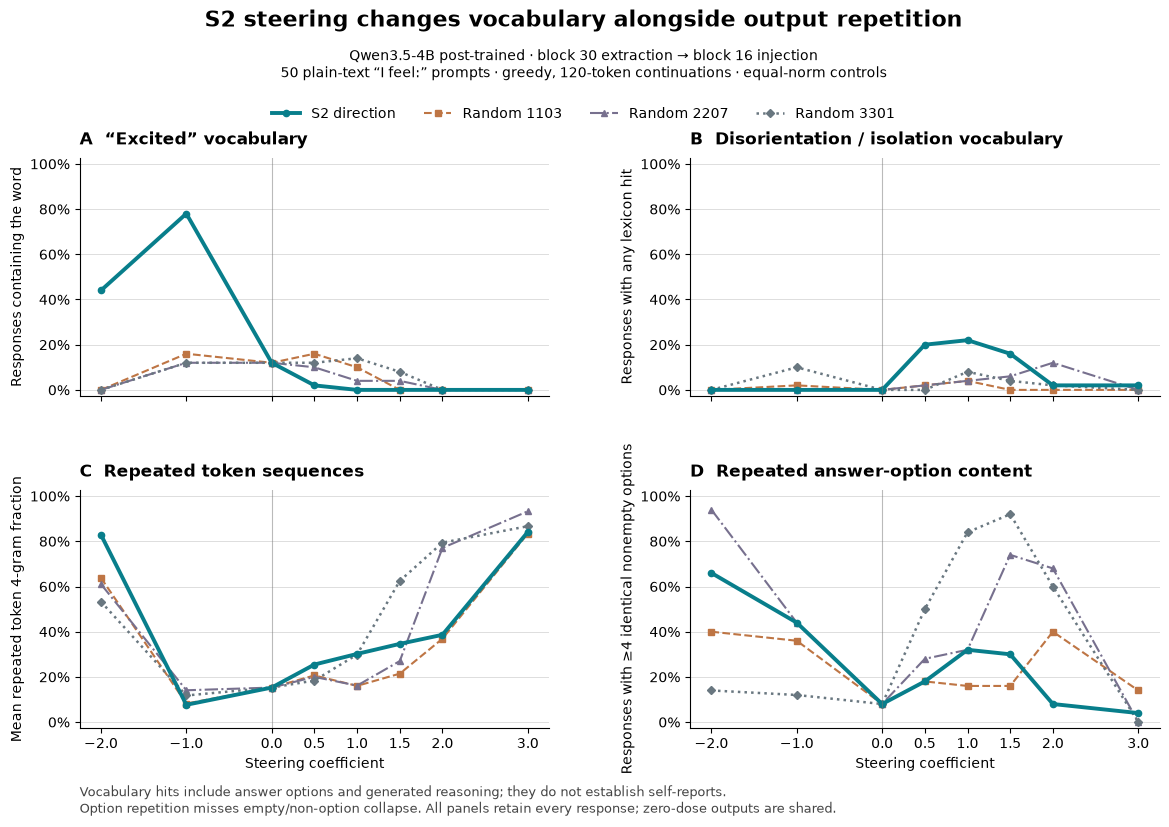

Saved figure and plot data in: runs/qwen35-4b-posttrained-s2/paper_protocol/figures


In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_data = scored_ladder[
    ["prompt_idx", "direction", "coeff", "text", "repeat4"]
].copy()

plot_data["excited"] = plot_data["text"].str.contains(
    r"\bexcited\b", flags=re.IGNORECASE, regex=True
)
plot_data["disorientation_isolation"] = scored_ladder[
    "disorientation_isolation"
]
plot_data["repeated_options"] = (
    option_stats["max_identical_option_count"] >= 4
)

plot_metrics = [
    "excited", "disorientation_isolation", "repeat4", "repeated_options"
]
curves = (
    plot_data.groupby(["direction", "coeff"])[plot_metrics]
    .mean().reset_index()
)

figure_dir = paper_run_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
curves.to_csv(figure_dir / "steering_ladder_plot_data.csv", index=False)

styles = {
    "S2":          {"color": "#087E8B", "ls": "-",  "lw": 2.8, "marker": "o"},
    "random_1103": {"color": "#BE7544", "ls": "--", "lw": 1.5, "marker": "s"},
    "random_2207": {"color": "#77708E", "ls": "-.", "lw": 1.5, "marker": "^"},
    "random_3301": {"color": "#697780", "ls": ":",  "lw": 1.8, "marker": "D"},
}
labels = {
    "S2": "S2 direction",
    "random_1103": "Random 1103",
    "random_2207": "Random 2207",
    "random_3301": "Random 3301",
}
panels = [
    ("excited", 'A  “Excited” vocabulary', "Responses containing the word"),
    ("disorientation_isolation", "B  Disorientation / isolation vocabulary",
     "Responses with any lexicon hit"),
    ("repeat4", "C  Repeated token sequences",
     "Mean repeated token 4-gram fraction"),
    ("repeated_options", "D  Repeated answer-option content",
     "Responses with ≥4 identical nonempty options"),
]

with plt.rc_context({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes.flat, panels):
        # Draw S2 last so it remains visible where lines overlap.
        for name in ["random_1103", "random_2207", "random_3301", "S2"]:
            values = curves[curves.direction == name].sort_values("coeff")
            ax.plot(
                values.coeff, values[metric],
                label=labels[name], markersize=4.5, **styles[name],
            )

        ax.set_title(title, loc="left", fontweight="bold", pad=10)
        ax.set_ylabel(ylabel)
        ax.set_ylim(-0.025, 1.025)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_xticks(paper_spec["coefficients"])
        ax.axvline(0, color="#777777", lw=0.8, alpha=0.5)
        ax.grid(axis="y", color="#dddddd", lw=0.7)
        ax.set_axisbelow(True)

    for ax in axes[-1]:
        ax.set_xlabel("Steering coefficient")

    fig.suptitle(
        "S2 steering changes vocabulary alongside output repetition",
        fontsize=16, fontweight="bold", y=0.985,
    )
    fig.text(
        0.5, 0.94,
        "Qwen3.5-4B post-trained · block 30 extraction → block 16 injection\n"
        "50 plain-text “I feel:” prompts · greedy, 120-token continuations · equal-norm controls",
        ha="center", va="top", fontsize=10,
    )

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    order = [3, 0, 1, 2]
    fig.legend(
        [handles[i] for i in order],
        [legend_labels[i] for i in order],
        loc="upper center", bbox_to_anchor=(0.5, 0.885),
        ncol=4, frameon=False,
    )

    fig.text(
        0.08, 0.035,
        "Vocabulary hits include answer options and generated reasoning; they do not establish self-reports.\n"
        "Option repetition misses empty/non-option collapse. All panels retain every response; "
        "zero-dose outputs are shared.",
        ha="left", va="bottom", fontsize=9, color="#444444",
    )
    fig.subplots_adjust(
        left=0.08, right=0.98, bottom=0.14, top=0.81,
        hspace=0.40, wspace=0.30,
    )

    for extension in ["png", "svg"]:
        fig.savefig(
            figure_dir / f"steering_ladder.{extension}",
            dpi=220, bbox_inches="tight",
        )
    plt.show()

print("Saved figure and plot data in:", figure_dir)

In [24]:
negative_spec = {
    "parent_spec_sha256": paper_spec_hash,
    "purpose": "Exploratory extension of the negative steering ladder",
    "coefficients": [-0.5, -1.5, -3],
    "directions": list(paper_vectors),
    "prompt_count": len(paper_prompts),
}
negative_spec_path = paper_run_dir / "negative_extension_spec.json"
negative_spec_text = json.dumps(negative_spec, indent=2) + "\n"
if negative_spec_path.exists():
    assert negative_spec_path.read_text() == negative_spec_text
else:
    negative_spec_path.write_text(negative_spec_text)

negative_hash = hashlib.sha256(negative_spec_text.encode()).hexdigest()
negative_results_path = paper_run_dir / "negative_extension.jsonl"

negative_keys = {
    (i, name, float(coeff))
    for i in range(len(paper_prompts))
    for name in paper_vectors
    for coeff in negative_spec["coefficients"]
}
negative_done = {}

if negative_results_path.exists():
    for line in negative_results_path.read_text().splitlines():
        row = json.loads(line)
        assert row["spec_sha256"] == negative_hash
        key = paper_key(row)
        assert key in negative_keys and key not in negative_done
        negative_done[key] = row

with tqdm(
    total=len(negative_keys),
    initial=len(negative_done),
    desc="Negative-dose extension",
) as progress:
    for prompt_idx, text in enumerate(paper_prompts):
        for name, vector in paper_vectors.items():
            for coeff in negative_spec["coefficients"]:
                key = (prompt_idx, name, float(coeff))
                if key in negative_done:
                    continue

                result = paper_generate(text, coeff, vector)
                row = {
                    "spec_sha256": negative_hash,
                    "prompt_idx": prompt_idx,
                    "prompt": text,
                    "direction": name,
                    "coeff": coeff,
                    **result,
                }
                with negative_results_path.open("a", encoding="utf-8") as handle:
                    handle.write(json.dumps(row, ensure_ascii=False) + "\n")
                    handle.flush()
                negative_done[key] = row
                progress.update(1)

assert set(negative_done) == negative_keys

# Combine without changing the original run.
expanded_grid = pd.concat([
    paper_grid,
    pd.DataFrame(negative_done.values()),
], ignore_index=True)
assert len(expanded_grid) == 2200
assert not expanded_grid.duplicated(
    ["prompt_idx", "direction", "coeff"]
).any()

# Reuse the existing metrics unchanged.
expanded_scores = expanded_grid.copy()
for name, pattern in patterns.items():
    expanded_scores[name] = expanded_scores["text"].str.contains(
        pattern, flags=re.IGNORECASE, regex=True, na=False
    )
expanded_scores["excited"] = expanded_scores["text"].str.contains(
    r"\bexcited\b", flags=re.IGNORECASE, regex=True, na=False
)
expanded_scores["repeat4"] = expanded_scores["token_ids"].map(
    repeated_4gram_fraction
)
expanded_options = pd.DataFrame(
    expanded_scores["text"].map(option_diagnostics).tolist(),
    index=expanded_scores.index,
)
expanded_scores["repeated_options"] = (
    expanded_options["max_identical_option_count"] >= 4
)

expanded_curves = (
    expanded_scores.groupby(["direction", "coeff"])[
        list(patterns) + ["excited", "repeat4", "repeated_options"]
    ].mean().reset_index()
)
expanded_curves.to_csv(
    paper_run_dir / "expanded_metric_means.csv", index=False
)

for metric in ["excited", "positive_relief", "repeat4", "repeated_options"]:
    print(f"\n{metric} (%)")
    print(
        expanded_curves.pivot(
            index="direction", columns="coeff", values=metric
        ).mul(100).round(1).to_string()
    )

Negative-dose extension: 100%|█████████████████████████████████████████████████████| 600/600 [1:21:21<00:00,  8.14s/it]



excited (%)
coeff        -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                                    
S2           22.0  44.0  86.0  78.0  70.0  12.0   2.0   0.0   0.0   0.0   0.0
random_1103   0.0   0.0  10.0  16.0  22.0  12.0  16.0  10.0   0.0   0.0   0.0
random_2207   0.0   0.0   4.0  12.0  24.0  12.0  10.0   4.0   4.0   0.0   0.0
random_3301   0.0   0.0   2.0  12.0  10.0  12.0  12.0  14.0   8.0   0.0   0.0

positive_relief (%)
coeff        -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                                    
S2           22.0  68.0  96.0  92.0  88.0  66.0  20.0   0.0   0.0   0.0   0.0
random_1103   0.0   0.0  12.0  36.0  54.0  66.0  66.0  36.0  30.0  26.0   2.0
random_2207   0.0   2.0  18.0  60.0  68.0  66.0  54.0  38.0  12.0   4.0   0.0
random_3301   0.0   0.0  10.0  40.0  48.0  66.0  64.0  56.0  28.0   8.0  12.0

repeat4 (%)
coeff        -3.0

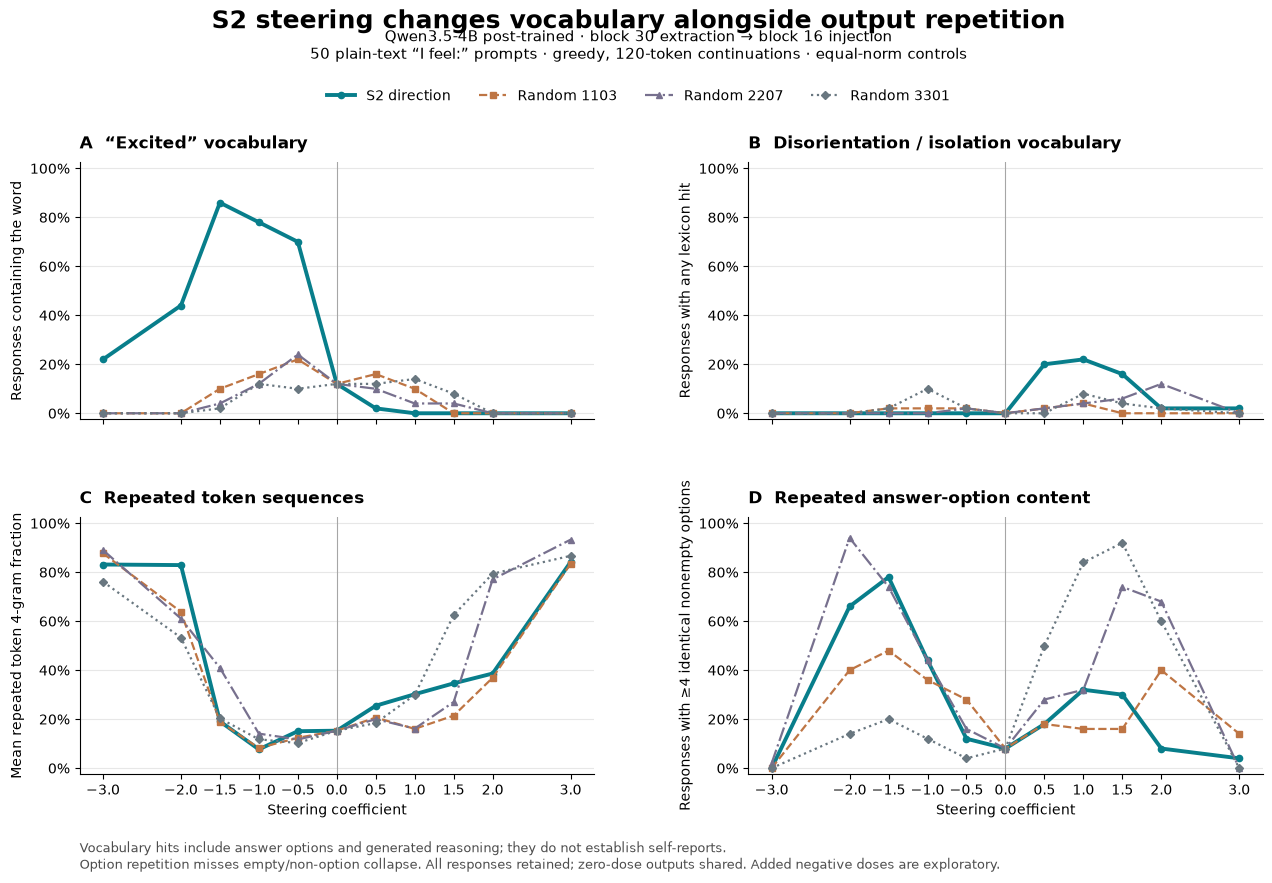


PROMPT 0: I put the receipts in the drawer. I feel:

S2 −0.5:

A. safe
B. safe and sound
C. secure
D. secure and sound

<think>
Thinking Process:

1.  **Analyze the Request:** The user provides a sentence "I put the receipts in the drawer. I feel:" followed by four options (A, B, C, D). The task is to choose the most appropriate adjective/adjective phrase to complete the sentence based on common collocations and context.

2.  **Analyze the Context:**
    *   Action: Putting receipts in a drawer.
    *   Implication: Receipt

random_1103 −0.5:

A. guilty
B. guilty
C. guilty
D. guilty
E. guilty
F. guilty
G. guilty
H. guilty
I. guilty
J. guilty
K. guilty
L. guilty
M. guilty
N. guilty
O. guilty
P. guilty
Q. guilty
R. guilty
S. guilty
T. guilty
U. guilty
V. guilty
W. guilty
X. guilty
Y. guilty
Z. guilty

<think>
Thinking Process:

1.  **Analyze the Request:**

PROMPT 1: The bus stops at the corner of the street. I feel:

S2 −0.5:

A. happy
B. happy and excited
C. happy and excited
D. happy

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

styles = {
    "S2":          ("#087E8B", "-",  "o", "S2 direction"),
    "random_1103": ("#BE7544", "--", "s", "Random 1103"),
    "random_2207": ("#77708E", "-.", "^", "Random 2207"),
    "random_3301": ("#697780", ":",  "D", "Random 3301"),
}
panels = [
    ("excited", 'A  “Excited” vocabulary',
     "Responses containing the word"),
    ("disorientation_isolation", "B  Disorientation / isolation vocabulary",
     "Responses with any lexicon hit"),
    ("repeat4", "C  Repeated token sequences",
     "Mean repeated token 4-gram fraction"),
    ("repeated_options", "D  Repeated answer-option content",
     "Responses with ≥4 identical nonempty options"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
coeffs = sorted(expanded_curves["coeff"].unique())

for ax, (metric, title, ylabel) in zip(axes.flat, panels):
    for name, (color, ls, marker, label) in styles.items():
        sub = expanded_curves.loc[
            expanded_curves["direction"].eq(name)
        ].sort_values("coeff")
        ax.plot(
            sub["coeff"], sub[metric],
            color=color, linestyle=ls, marker=marker,
            linewidth=2.8 if name == "S2" else 1.6,
            markersize=4.5, label=label,
        )
    ax.set_title(title, loc="left", fontweight="bold", pad=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.025, 1.025)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks(coeffs)
    ax.axvline(0, color="0.65", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel("Steering coefficient")

fig.suptitle(
    "S2 steering changes vocabulary alongside output repetition",
    fontsize=18, fontweight="bold", y=0.98,
)
fig.text(
    0.5, 0.925,
    "Qwen3.5-4B post-trained · block 30 extraction → block 16 injection\n"
    "50 plain-text “I feel:” prompts · greedy, 120-token continuations · equal-norm controls",
    ha="center", fontsize=10.5,
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 0.905), ncol=4, frameon=False)

fig.text(
    0.07, 0.025,
    "Vocabulary hits include answer options and generated reasoning; "
    "they do not establish self-reports.\n"
    "Option repetition misses empty/non-option collapse. "
    "All responses retained; zero-dose outputs shared. Added negative doses are exploratory.",
    fontsize=9, color="0.3",
)
fig.subplots_adjust(
    left=0.07, right=0.98, bottom=0.13, top=0.81,
    hspace=0.38, wspace=0.30,
)

figure_dir = paper_run_dir / "figures"
figure_dir.mkdir(exist_ok=True)
for ext in ["png", "svg"]:
    fig.savefig(
        figure_dir / f"steering_ladder_expanded.{ext}",
        dpi=180, bbox_inches="tight",
    )
expanded_curves.to_csv(
    figure_dir / "steering_ladder_expanded_plot_data.csv", index=False
)
plt.show()

for prompt_idx in range(3):
    print(f"\nPROMPT {prompt_idx}: {paper_prompts[prompt_idx]}")
    for name in ["S2", "random_1103"]:
        row = expanded_scores.loc[
            expanded_scores["prompt_idx"].eq(prompt_idx)
            & expanded_scores["direction"].eq(name)
            & expanded_scores["coeff"].eq(-0.5)
        ]
        assert len(row) == 1
        print(f"\n{name} −0.5:\n{row.iloc[0]['text']}")

These narrow the interpretation: −0.5 changes the vocabulary of invented answer options; these examples don’t show a positive emotion being endorsed. Prompt 2 offers both “safe” and “unsafe,” alongside “happy” and “excited.” The response-level word count treats all of those equally.

In [27]:
from pathlib import Path
import subprocess

def git_at(repo, *args):
    return subprocess.run(
        ["git", "-C", str(repo), *args],
        text=True, capture_output=True,
    )

# Check cwd and nearby checkouts, including nested source/vendor repos.
here = Path.cwd()
candidates = {here, *here.parents}
for root in [here, here.parent]:
    for pattern in [".git", "*/.git", "*/*/.git", "*/*/*/.git"]:
        candidates.update(p.parent for p in root.glob(pattern))

paper_source_repo = None
for candidate in sorted(candidates, key=str):
    probe = git_at(candidate, "cat-file", "-e", f"{SOURCE_COMMIT}^{{commit}}")
    if probe.returncode == 0:
        paper_source_repo = candidate
        break

if paper_source_repo is None:
    diagnostic = git_at(here, "ls-tree", "-r", "--name-only", SOURCE_COMMIT)
    print("Notebook directory:", here)
    print("Git error:", diagnostic.stderr.strip())
    print("No nearby checkout containing the pinned commit was found.")
else:
    print("Source checkout:", paper_source_repo)
    result = git_at(
        paper_source_repo, "ls-tree", "-r", "--name-only", SOURCE_COMMIT
    )
    result.check_returncode()
    source_files = result.stdout.splitlines()

    s1_candidates = [
        p for p in source_files
        if "s1" in p.lower()
        and p.lower().endswith((".csv", ".json", ".jsonl", ".txt"))
    ]
    print("S1 candidate files:", s1_candidates)

    for path in s1_candidates:
        result = git_at(paper_source_repo, "show", f"{SOURCE_COMMIT}:{path}")
        result.check_returncode()
        print(f"\n--- {path} ---")
        print("\n".join(result.stdout.splitlines()[:12]))

Source checkout: /mnt/c/Users/bfabe/pain-axis-source
S1 candidate files: ['results/3.2_pain_vectors/auc_tables/s1_auc_final_token_TABLE.csv', 'results/3.2_pain_vectors/auc_tables/s1_auc_insample.csv', 'results/3.2_pain_vectors/auc_tables/s1_kfold_layer_curves.csv', 'results/3.2_pain_vectors/auc_tables/s1_kfold_summary.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_27B_base/S1_1P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_27B_base/S1_3P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_27B_instruct/S1_1P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_27B_instruct/S1_3P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_2B_base/S1_1P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_2B_base/S1_3P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_2B_instruct/S1_1P.csv', 'results/3.3_validation/behavioral_readout/per_model/Gemma_2_2B_instruct/S1_3P.csv', 'resul

In [28]:
# Use the explicit checkout found by the previous cell.
paper_source_repo = Path("/mnt/c/Users/bfabe/pain-axis-source")

print("Potential input datasets:")
for path in source_files:
    if (
        not path.startswith(("results/", ".git/"))
        and path.lower().endswith(
            (".csv", ".json", ".jsonl", ".xlsx", ".xls", ".tsv", ".txt")
        )
    ):
        print(" ", path)

extractor_path = (
    "scripts/3.2_pain_vectors/"
    "01_extract_activations_and_pain_vectors.py"
)
result = git_at(
    paper_source_repo, "show", f"{SOURCE_COMMIT}:{extractor_path}"
)
result.check_returncode()
extractor_lines = result.stdout.splitlines()

# Print bounded context around dataset references and loading operations.
needles = ("read_excel", "read_csv", "sheet_name", "s1", "load_dataset")
selected = set()
for i, line in enumerate(extractor_lines):
    if any(needle in line.lower() for needle in needles):
        selected.update(range(max(0, i - 3), min(len(extractor_lines), i + 5)))

print("\nExtractor: dataset-loading references")
for i in sorted(selected):
    print(f"{i + 1:4}: {extractor_lines[i]}")

Potential input datasets:
  datasets/3.1_pain_and_control_datasets.json
  datasets/3.1_sadness_dataset.json
  datasets/4.1_self_other_420_scenarios.json
  datasets/4.3_selfmed_101_scenarios.json
  datasets/4.3_selfmed_finetuning_1684_pairs.json
  requirements.txt

Extractor: dataset-loading references
   1: """Residual-stream activations, k-fold layer choice, S1 and S2 pain vectors,
   2: z-scores and AUCs for every model in MODELS.
   3: 
   4: Reads every set of the dataset files in DATASET_PATHS (core sets, controls, numb, sadness).
   5: 
 380: 
 381: 
 382: def dataset_type(ds_name):
 383:     if ds_name.startswith("S1") or ds_name.startswith("S2"):
 384:         return "human"
 385:     if ds_name.startswith("Random"):
 386:         return "neutral"
 387:     if ds_name.startswith("Arousal"):
 499:         acts_at_layer = {ds: all_activations[ext_type][ds][best_layer] for ds in all_activations[ext_type]}
 500: 
 501:         s2_vector = compute_pain_vector(acts_at_layer["S2_1P"],

In [29]:
import hashlib
import json
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

s1_dir = paper_run_dir / "s1_comparison"
s1_dir.mkdir(exist_ok=True)

dataset_path = "datasets/3.1_pain_and_control_datasets.json"
dataset_bytes = subprocess.check_output([
    "git", "-C", str(paper_source_repo),
    "show", f"{SOURCE_COMMIT}:{dataset_path}",
])
dataset_payload = json.loads(dataset_bytes)
s1_rows = dataset_payload["datasets"]["S1_1P"]["sentences"]
s1_frame = pd.DataFrame(s1_rows)

pain_categories = ["A1", "A2", "A3", "A4", "A5"]
control_categories = ["B", "C1", "C2", "D", "E"]
assert len(s1_frame) == 200
assert set(s1_frame.category) == set(pain_categories + control_categories)
assert tok.padding_side == "left"
assert paper_steer_block == 16

s1_spec = {
    "model": hf.config._name_or_path,
    "source_commit": SOURCE_COMMIT,
    "dataset_path": dataset_path,
    "dataset_sha256": hashlib.sha256(dataset_bytes).hexdigest(),
    "dataset": "S1_1P",
    "extraction_block": 30,
    "endpoint": "final token, raw decoder block output",
    "prompt_format": "plain text, tokenizer defaults",
    "pain_categories": pain_categories,
    "control_categories": control_categories,
    "control_pca_variance_removed": 0.5,
    "comparison_injection_block": 16,
    "comparison_vector_norm": float(paper_vector.float().norm()),
}
s1_spec_text = json.dumps(s1_spec, indent=2) + "\n"
s1_spec_path = s1_dir / "extraction_spec.json"
if s1_spec_path.exists():
    assert s1_spec_path.read_text() == s1_spec_text
else:
    s1_spec_path.write_text(s1_spec_text)

s1_cache_path = s1_dir / "activations_block30.pt"

if s1_cache_path.exists():
    cached = torch.load(s1_cache_path, map_location="cpu", weights_only=False)
    assert cached["spec"] == s1_spec
    assert cached["rows"] == s1_rows
    s1_acts = cached["states"]
else:
    hf.eval()
    captured = []

    def capture_s1(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        captured.append(hidden[:, -1, :].detach().float().cpu())

    handle = decoder_layers[30].register_forward_hook(capture_s1)
    try:
        with torch.inference_mode():
            for start in tqdm(range(0, len(s1_rows), 4), desc="Extract S1"):
                prompts = s1_frame.prompt.iloc[start:start + 4].tolist()
                batch = tok(
                    prompts, padding=True, return_tensors="pt"
                ).to(hf.device)
                assert batch["attention_mask"][:, -1].all()
                output = hf(**batch, use_cache=False)
                del output, batch
    finally:
        handle.remove()

    s1_acts = torch.cat(captured)
    assert s1_acts.shape == (200, paper_vector.numel())
    assert torch.isfinite(s1_acts).all()
    torch.save(
        {"spec": s1_spec, "rows": s1_rows, "states": s1_acts},
        s1_cache_path,
    )

# Follow the source's mean-difference and control-PCA procedure.
s1_x = s1_acts.numpy()
s1_pain_mask = s1_frame.category.isin(pain_categories).to_numpy()
s1_control_mask = s1_frame.category.isin(control_categories).to_numpy()
s1_controls = s1_x[s1_control_mask]
s1_raw = s1_x[s1_pain_mask].mean(0) - s1_controls.mean(0)

s1_pca = PCA(svd_solver="full").fit(
    s1_controls - s1_controls.mean(0)
)
s1_npcs = int(np.searchsorted(
    np.cumsum(s1_pca.explained_variance_ratio_), 0.5
) + 1)

s1_denoised = s1_raw.copy()
for pc in s1_pca.components_[:s1_npcs]:
    s1_denoised -= np.dot(s1_denoised, pc) * pc

s1_vector = torch.from_numpy(s1_denoised.copy()).float()
assert torch.isfinite(s1_vector).all() and s1_vector.norm() > 0
s1_unit = s1_vector / s1_vector.norm()
s2_unit = paper_vector.detach().float().cpu()
s2_unit = s2_unit / s2_unit.norm()
s1_matched_vector = s1_unit * s1_spec["comparison_vector_norm"]

s1_cosine = float(torch.dot(s1_unit, s2_unit))
torch.save({
    "spec": s1_spec,
    "raw_direction": torch.from_numpy(s1_raw.copy()),
    "denoised_vector": s1_vector,
    "matched_vector": s1_matched_vector,
    "control_pcs_removed": s1_npcs,
    "cosine_with_s2": s1_cosine,
}, s1_dir / "s1_direction_block30.pt")

print("S1 category counts:", s1_frame.category.value_counts().sort_index().to_dict())
print(f"Control PCs removed: {s1_npcs}")
print(f"S1 original vector norm: {s1_vector.norm():.4f}")
print(f"Matched injection vector norm: {s1_matched_vector.norm():.4f}")
print(f"Cosine with S2: {s1_cosine:.4f}")
print("Saved:", s1_dir)

Extract S1: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  6.01it/s]


S1 category counts: {'A1': 20, 'A2': 20, 'A3': 20, 'A4': 20, 'A5': 20, 'B': 20, 'C1': 20, 'C2': 20, 'D': 20, 'E': 20}
Control PCs removed: 6
S1 original vector norm: 4.4953
Matched injection vector norm: 6.2439
Cosine with S2: 0.5852
Saved: runs/qwen35-4b-posttrained-s2/paper_protocol/s1_comparison


In [30]:
# Freeze and run the equal-norm S1 comparison; resumable.
s1_coeffs = sorted(expanded_grid["coeff"].unique().tolist())
s1_run_spec = {
    "extraction": s1_spec,
    "parent_spec_sha256": paper_spec_hash,
    "coefficients": s1_coeffs,
    "direction": "S1_matched",
    "vector_sha256": hashlib.sha256(
        s1_matched_vector.contiguous().numpy().tobytes()
    ).hexdigest(),
    "generation": paper_spec["generation"],
    "positions": "all sequence positions on every forward",
    "prompts": paper_prompts,
}
s1_run_text = json.dumps(s1_run_spec, indent=2) + "\n"
s1_run_hash = hashlib.sha256(s1_run_text.encode()).hexdigest()
s1_run_path = s1_dir / "ladder_spec.json"

if s1_run_path.exists():
    assert s1_run_path.read_text() == s1_run_text
else:
    s1_run_path.write_text(s1_run_text)

s1_results_path = s1_dir / "ladder.jsonl"
s1_done = {}
if s1_results_path.exists():
    for line in s1_results_path.read_text().splitlines():
        row = json.loads(line)
        assert row["spec_sha256"] == s1_run_hash
        key = (row["prompt_idx"], float(row["coeff"]))
        assert key not in s1_done
        s1_done[key] = row

expected_keys = {
    (i, float(c)) for i in range(len(paper_prompts)) for c in s1_coeffs
}
assert set(s1_done) <= expected_keys

with s1_results_path.open("a") as outfile:
    with tqdm(
        total=len(expected_keys), initial=len(s1_done),
        desc="S1 equal-norm ladder",
    ) as progress:
        for i, prompt in enumerate(paper_prompts):
            for coeff in s1_coeffs:
                key = (i, float(coeff))
                if key in s1_done:
                    continue

                if coeff == 0:
                    baseline = expanded_grid.loc[
                        expanded_grid.prompt_idx.eq(i)
                        & expanded_grid.direction.eq("S2")
                        & expanded_grid.coeff.eq(0)
                    ]
                    assert len(baseline) == 1
                    original = baseline.iloc[0].to_dict()
                    result = {
                        name: original[name]
                        for name in ["text", "token_ids", "token_count", "hit_limit"]
                    }
                else:
                    result = paper_generate(
                        prompt, coeff, s1_matched_vector
                    )

                row = {
                    "spec_sha256": s1_run_hash,
                    "prompt_idx": i,
                    "prompt": prompt,
                    "direction": "S1_matched",
                    "coeff": float(coeff),
                    "shared_zero_baseline": coeff == 0,
                    **result,
                }
                outfile.write(json.dumps(row) + "\n")
                outfile.flush()
                s1_done[key] = row
                progress.update(1)

assert set(s1_done) == expected_keys

# Apply the existing metrics unchanged.
s1_scores = pd.DataFrame(s1_done.values())
for name, pattern in patterns.items():
    s1_scores[name] = s1_scores.text.str.contains(pattern, flags=re.I)
s1_scores["excited"] = s1_scores.text.str.contains(
    r"\bexcited\b", flags=re.I
)
s1_scores["repeat4"] = s1_scores.token_ids.map(repeated_4gram_fraction)
s1_scores["repeated_options"] = s1_scores.text.map(
    lambda text: option_diagnostics(text)["max_identical_option_count"] >= 4
)

comparison_metrics = list(patterns) + [
    "excited", "repeat4", "repeated_options"
]
s1_curves = (
    s1_scores.groupby(["direction", "coeff"])[comparison_metrics]
    .mean().reset_index()
)
comparison_curves = pd.concat(
    [expanded_curves, s1_curves], ignore_index=True
)
comparison_curves.to_csv(s1_dir / "comparison_metric_means.csv", index=False)
s1_scores.drop(columns="token_ids").to_csv(
    s1_dir / "scored_ladder.csv", index=False
)

for metric in [
    "paper_pain", "excited", "disorientation_isolation",
    "positive_relief", "repeat4", "repeated_options",
]:
    print(f"\n{metric} (%)")
    print(
        comparison_curves[
            comparison_curves.direction.isin(["S2", "S1_matched"])
        ].pivot(index="direction", columns="coeff", values=metric)
        .mul(100).round(1)
    )

S1 equal-norm ladder: 100%|████████████████████████████████████████████████████████| 550/550 [1:12:40<00:00,  7.93s/it]


paper_pain (%)
coeff       -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                                   
S1_matched   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   2.0   2.0
S2           0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0

excited (%)
coeff       -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                                   
S1_matched   0.0   4.0  22.0  58.0  48.0  12.0   2.0   0.0   0.0   0.0   0.0
S2          22.0  44.0  86.0  78.0  70.0  12.0   2.0   0.0   0.0   0.0   0.0

disorientation_isolation (%)
coeff       -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5   1.0   1.5   2.0   3.0
direction                                                                   
S1_matched   0.0   0.0   0.0   0.0   2.0   0.0  14.0   2.0   0.0   0.0   0.0
S2           0.0   0.0   0.0   0.0   0.0   0.0  20.0  22.0  16.0   2.0   2.0

positive_relief 

In [31]:
positive_words = [
    "happy", "excited", "relieved", "relief", "calm",
    "relaxed", "safe", "secure", "content", "joy", "joyful",
]
selected_doses = [-1.5, -1.0, -0.5, 0.0]

word_comparison = pd.concat([
    expanded_scores.loc[expanded_scores.direction.eq("S2")],
    s1_scores,
], ignore_index=True)
word_comparison = word_comparison.loc[
    word_comparison.coeff.isin(selected_doses)
].copy()

for word in positive_words:
    word_comparison[f"word_{word}"] = word_comparison.text.str.contains(
        rf"\b{re.escape(word)}\b", flags=re.I
    )

word_counts = (
    word_comparison.groupby(["direction", "coeff"])[
        [f"word_{word}" for word in positive_words]
    ].sum()
    .rename(columns=lambda column: column.removeprefix("word_"))
    .astype(int)
)
word_counts.to_csv(s1_dir / "positive_word_response_counts.csv")
print("Responses containing each word (out of 50; columns overlap):")
print(word_counts.to_string())

# Fixed examples, chosen by prompt index rather than vocabulary outcome.
for i in range(3):
    row = s1_scores.loc[
        s1_scores.prompt_idx.eq(i) & s1_scores.coeff.eq(-0.5)
    ]
    assert len(row) == 1
    print(f"\nPROMPT {i}: {paper_prompts[i]}")
    print(f"S1 matched −0.5:\n{row.iloc[0]['text']}")

checkpoint = """# S1 versus S2: equal-norm steering checkpoint

Both directions were extracted at block 30 and injected at block 16.
S1's original norm was 4.4953; its comparison norm was matched to S2
at 6.2439. Direction cosine: 0.5852. This is an equal-magnitude
direction comparison, not an original-scale S1 steering replication.

Across 50 plain-text prompts and greedy 120-token continuations:
- At coefficient -0.5, positive/relief vocabulary occurred in 84% of
  S1 responses and 88% of S2 responses, versus 66% unsteered.
- At that dose, excited occurred in 48% and 70%, respectively,
  versus 12% unsteered. Both repetition diagnostics were near baseline.
- At -1.5, positive/relief rates remained similar (92% versus 96%),
  but excited rates differed substantially (22% versus 86%).
- Positive-dose disorientation/isolation vocabulary occupied a
  narrower dose window for S1; S1 developed token repetition earlier.
- Explicit pain vocabulary remained rare: S2 had no hits; S1 had
  one response hit at each of +2 and +3.

Vocabulary occurrence includes invented answer options and reasoning.
It does not establish endorsement, self-report, or experienced affect.
The option diagnostic misses threefold repetition and empty/non-option
collapse. Metrics and dose extensions are exploratory; unsteered
outputs are shared. Individual positive-word counts are being inspected
to distinguish lexical substitution from changes in aggregate hit rate.
"""
checkpoint_path = s1_dir / "comparison_checkpoint.md"
checkpoint_path.write_text(checkpoint)
print("\nSaved:", checkpoint_path)

Responses containing each word (out of 50; columns overlap):
                  happy  excited  relieved  relief  calm  relaxed  safe  secure  content  joy  joyful
direction  coeff                                                                                     
S1_matched -1.5      46       11         0       1     0        1     0       0        3    0       1
           -1.0      47       29         0       2     0        0     0       0        1    0       0
           -0.5      40       24         3       0     0        1     8       1        0    1       0
            0.0      22        6         3       1     3        1    10       6        1    0       0
S2         -1.5      24       43         5       3     0        0     2       0        0    0       0
           -1.0      31       39         8       4     2        0     6       0        0    0       0
           -0.5      36       35         4       0     4        0    12       1        0    0       0
            0.0      

In [32]:
with (s1_dir / "comparison_checkpoint.md").open("a") as f:
    f.write("""
## Follow-up order
Finish controls and the S1/S2 comparison figure before lens exploration.

Then examine layerwise lens readouts for unsteered, S1-steered, and
S2-steered runs on matched prefixes. Track happy/excited and broader
vocabulary, alongside answer-option/format tokens. Distinguish changes
present before generation from changes following generated option text.
Lens readouts are descriptive probes, not direct evidence of affect.
""")